# **Part 3: Modelling, Evaluation, and Expected Loss**

Covers Weight of Evidence and Information Value, the logistic regression baseline, evaluation under class imbalance, the gradient boosting comparison, expected loss and the scorecard, and temporal validation.

In [1]:
# All libraries used in this notebook, collected here so it runs cleanly from top to bottom
import os

import pandas as pd                  # loading and reshaping the loan data
import numpy as np                   # log transforms for WoE, and array handling
import matplotlib.pyplot as plt      # evaluation figures and the approval curve
from scipy.stats import ks_2samp     # KS statistic

from sklearn.model_selection import train_test_split   # splitting into train and test sets
from sklearn.linear_model import LogisticRegression    # the baseline model
from sklearn.metrics import (
    roc_auc_score,      # ROC-AUC
    roc_curve,          # ROC curve points and threshold selection
    confusion_matrix,   # true/false positives and negatives at a chosen threshold
    precision_score,    # share of flagged loans that actually defaulted
    recall_score        # share of actual defaults the model caught
)
from xgboost import XGBClassifier    # gradient boosting comparison model

# Charts are written here as they're produced
os.makedirs('figures', exist_ok=True)

In [2]:
# Loading the cleaned dataset 
import pandas as pd

model_df = pd.read_csv('Model df cleaned.csv')
model_df.shape  

(74976, 46)

## **Stage 5: Weight of Evidence and Information Value**

Every variable needs converting onto the same numeric scale before it can go into a model, a dollar amount and a two-letter state code aren't comparable as they stand. This builds one function to do that conversion for any variable, then applies it to each one in turn, starting with loan size.

**WOE and IV for Loan Size**

In [3]:
# Building the same loan size bands used in the exploratory analysis
model_df['LoanSizeBand'] = pd.cut(
    model_df['GrossApproval'],
    bins=[0, 50000, 150000, 350000, 1000000, float('inf')],
    labels=['Under $50k', '$50k-$150k', '$150k-$350k', '$350k-$1M', 'Over $1M']
)

# Counting how many good (paid in full) and bad (charged off) loans fall in each band
woe_table = model_df.groupby('LoanSizeBand', observed=True)['default'].agg(
    bad_count='sum',
    total_count='count'
)
woe_table['good_count'] = woe_table['total_count'] - woe_table['bad_count']

woe_table

,bad_count,total_count,good_count
LoanSizeBand,,,
Under $50k,3337,21763,18426
$50k-$150k,2022,16256,14234
$150k-$350k,909,13445,12536
$350k-$1M,394,13009,12615
Over $1M,164,10503,10339


In [4]:
# Total good and bad loans across the whole dataset, not just one band
total_bad = woe_table['bad_count'].sum()
total_good = woe_table['good_count'].sum()

# Finding what fraction of ALL bad loans and good loans are in this band
woe_table['pct_bad'] = woe_table['bad_count'] / total_bad
woe_table['pct_good'] = woe_table['good_count'] / total_good

# Adding a totals row showing the sum of each column
totals_row = pd.DataFrame({
    'bad_count': [woe_table['bad_count'].sum()],
    'total_count': [woe_table['total_count'].sum()],
    'good_count': [woe_table['good_count'].sum()],
    'pct_bad': [woe_table['pct_bad'].sum()],
    'pct_good': [woe_table['pct_good'].sum()],
}, index=['Total'])

woe_table_with_total = pd.concat([woe_table, totals_row])

woe_table_with_total

,bad_count,total_count,good_count,pct_bad,pct_good
Under $50k,3337,21763,18426,0.488866,0.270374
$50k-$150k,2022,16256,14234,0.296220,0.208863
$150k-$350k,909,13445,12536,0.133167,0.183947
$350k-$1M,394,13009,12615,0.057720,0.185106
Over $1M,164,10503,10339,0.024026,0.151709
Total,6826,74976,68150,1.000000,1.000000


In [5]:
import numpy as np  # provides the natural log function

# WoE formula: log of (share of good loans / share of bad loans) in each band
woe_table['WoE'] = np.log(woe_table['pct_good'] / woe_table['pct_bad'])

woe_table

,bad_count,total_count,good_count,pct_bad,pct_good,WoE
LoanSizeBand,,,,,,
Under $50k,3337,21763,18426,0.488866,0.270374,-0.592282
$50k-$150k,2022,16256,14234,0.296220,0.208863,-0.349426
$150k-$350k,909,13445,12536,0.133167,0.183947,0.323042
$350k-$1M,394,13009,12615,0.057720,0.185106,1.165319
Over $1M,164,10503,10339,0.024026,0.151709,1.842840


In [6]:
# IV formula: difference between good% and bad% in each band, multiplied by that band's WoE, summed up
woe_table['IV_contribution'] = (woe_table['pct_good'] - woe_table['pct_bad']) * woe_table['WoE']

# Adding up each band's contribution gives the total Information Value for this variable
total_iv = woe_table['IV_contribution'].sum()
print(f"Information Value for LoanSizeBand is: {total_iv:.4f}")

Information Value for LoanSizeBand is: 0.5601


**WOE and IV for Business age**

In [7]:
# Counting good and bad loans within each existing BusinessAge category
woe_age = model_df.groupby('BusinessAge')['default'].agg(
    bad_count='sum',
    total_count='count'
)
woe_age['good_count'] = woe_age['total_count'] - woe_age['bad_count']

# Working out each category's share of all bad loans, and share of all good loans
total_bad = woe_age['bad_count'].sum()
total_good = woe_age['good_count'].sum()
woe_age['pct_bad'] = woe_age['bad_count'] / total_bad
woe_age['pct_good'] = woe_age['good_count'] / total_good

# The WoE formula: log of (share of good loans / share of bad loans)
woe_age['WoE'] = np.log(woe_age['pct_good'] / woe_age['pct_bad'])

# The IV formula: difference between good% and bad%, multiplied by WoE, summed across categories
woe_age['IV_contribution'] = (woe_age['pct_good'] - woe_age['pct_bad']) * woe_age['WoE']
total_iv_age = woe_age['IV_contribution'].sum()

print(f"Information Value for BusinessAge: {total_iv_age:.4f}")
woe_age

Information Value for BusinessAge: 0.0918


,bad_count,total_count,good_count,pct_bad,pct_good,WoE,IV_contribution
BusinessAge,,,,,,,
Change of Ownership,338,7483,7145,0.049517,0.104842,0.750150,0.041503
Existing or more than 2 years old,3487,40843,37356,0.510841,0.548144,0.070479,0.002629
New Business or 2 years or less,1749,12723,10974,0.256226,0.161027,-0.464488,0.044219
"Startup, Loan Funds will Open Business",1086,11455,10369,0.159098,0.152150,-0.044653,0.000310
Unanswered,166,2472,2306,0.024319,0.033837,0.330310,0.003144


**WoE and IV for NaicsSector**

In [8]:

# Counting good and bad loans within each industry sector
woe_sector = model_df.groupby('NaicsSector')['default'].agg(
    bad_count='sum',
    total_count='count'
)
woe_sector['good_count'] = woe_sector['total_count'] - woe_sector['bad_count']

# Working out each sector's share of all bad loans, and share of all good loans
total_bad = woe_sector['bad_count'].sum()
total_good = woe_sector['good_count'].sum()
woe_sector['pct_bad'] = woe_sector['bad_count'] / total_bad
woe_sector['pct_good'] = woe_sector['good_count'] / total_good

# The WoE formula: log of (share of good loans / share of bad loans)
woe_sector['WoE'] = np.log(woe_sector['pct_good'] / woe_sector['pct_bad'])

# The IV formula: difference between good% and bad%, multiplied by WoE, summed across sectors
woe_sector['IV_contribution'] = (woe_sector['pct_good'] - woe_sector['pct_bad']) * woe_sector['WoE']
total_iv_sector = woe_sector['IV_contribution'].sum()

print(f"Information Value for NaicsSector: {total_iv_sector:.4f}")

# Sorting by WoE, not count, so I can spot any sector with an extreme value likely caused by a tiny sample size
woe_sector.sort_values('WoE')

Information Value for NaicsSector: inf


,bad_count,total_count,good_count,pct_bad,pct_good,WoE,IV_contribution
NaicsSector,,,,,,,
48,830,5312,4482,0.121594,0.065767,-0.614573,0.034310
49,61,445,384,0.008936,0.005635,-0.461204,0.001523
45,443,3303,2860,0.064899,0.041966,-0.435965,0.009998
22,15,137,122,0.002197,0.001790,-0.205001,0.000083
42,394,3702,3308,0.057720,0.048540,-0.173224,0.001590
71,229,2195,1966,0.033548,0.028848,-0.150938,0.000709
61,99,960,861,0.014503,0.012634,-0.137998,0.000258
51,70,700,630,0.010255,0.009244,-0.103748,0.000105
54,675,6889,6214,0.098887,0.091181,-0.081125,0.000625


As the WOE and IV of sector '55' is infinity due to zero bad loan as the sample size is just 44 loans so it's affecting the overall IV which needs to be resolved

In [9]:
# Counting loans per sector, so I know which ones are too small to stand alone
sector_counts = model_df['NaicsSector'].value_counts()

# Any sector with fewer than 100 loans gets grouped into a single "Other" category
small_sectors = sector_counts[sector_counts < 100].index
model_df['NaicsSectorGrouped'] = model_df['NaicsSector'].where(~model_df['NaicsSector'].isin(small_sectors), 'Other')

model_df['NaicsSectorGrouped'].value_counts()

NaicsSectorGrouped
23       10031
72        8894
54        6889
62        6155
81        6134
44        5897
48        5312
56        4236
42        3702
45        3303
33        2400
71        2195
53        2017
52        1761
31        1336
32        1143
11        1066
61         960
51         700
49         445
21         195
22         137
Other       68
Name: count, dtype: int64

In [10]:
# Double-checking that no sector (including the new "Other" group) has zero defaults, which would break WoE again
model_df.groupby('NaicsSectorGrouped')['default'].sum().sort_values()

NaicsSectorGrouped
Other      1
21         2
22        15
11        40
32        57
49        61
51        70
52        90
31        94
61        99
33       140
53       175
71       229
62       341
42       394
56       403
45       443
44       459
81       551
54       675
72       696
48       830
23       961
Name: default, dtype: int64

In [11]:
# Calculating WoE and IV for NaicsSectorGrouped again (small sectors combined into "Other")

# Counting good and bad loans within each grouped sector
woe_sector = model_df.groupby('NaicsSectorGrouped')['default'].agg(
    bad_count='sum',
    total_count='count'
)
woe_sector['good_count'] = woe_sector['total_count'] - woe_sector['bad_count']

# Working out each sector's share of all bad loans, and share of all good loans
total_bad = woe_sector['bad_count'].sum()
total_good = woe_sector['good_count'].sum()
woe_sector['pct_bad'] = woe_sector['bad_count'] / total_bad
woe_sector['pct_good'] = woe_sector['good_count'] / total_good

# The WoE formula: log of (share of good loans / share of bad loans)
woe_sector['WoE'] = np.log(woe_sector['pct_good'] / woe_sector['pct_bad'])

# The IV formula: difference between good% and bad%, multiplied by WoE, summed across sectors
woe_sector['IV_contribution'] = (woe_sector['pct_good'] - woe_sector['pct_bad']) * woe_sector['WoE']
total_iv_sector = woe_sector['IV_contribution'].sum()

print(f"Information Value for NaicsSectorGrouped: {total_iv_sector:.4f}")

# Sorting by WoE to see the full risk ordering, riskiest sectors first
woe_sector.sort_values('WoE')

Information Value for NaicsSectorGrouped: 0.1093


,bad_count,total_count,good_count,pct_bad,pct_good,WoE,IV_contribution
NaicsSectorGrouped,,,,,,,
48,830,5312,4482,0.121594,0.065767,-0.614573,0.034310
49,61,445,384,0.008936,0.005635,-0.461204,0.001523
45,443,3303,2860,0.064899,0.041966,-0.435965,0.009998
22,15,137,122,0.002197,0.001790,-0.205001,0.000083
42,394,3702,3308,0.057720,0.048540,-0.173224,0.001590
71,229,2195,1966,0.033548,0.028848,-0.150938,0.000709
61,99,960,861,0.014503,0.012634,-0.137998,0.000258
51,70,700,630,0.010255,0.009244,-0.103748,0.000105
54,675,6889,6214,0.098887,0.091181,-0.081125,0.000625


**WOE and IV for Borrower States**

In [12]:
# Checking for any state with zero defaults, before running WoE
model_df.groupby('BorrState')['default'].sum().sort_values()

BorrState
GU      0
AK      1
VI      1
ND      4
VT     10
WV     13
WY     14
MT     14
PR     15
ME     16
NM     17
NE     17
RI     18
SD     19
AR     22
HI     24
ID     24
NH     26
KS     26
IA     33
DC     35
MS     37
DE     40
KY     41
AL     43
OK     44
LA     57
SC     66
TN     67
OR     83
UT     83
IN     90
NC     92
WI     94
MO     96
CT     98
NV    101
VA    107
WA    128
AZ    128
MA    141
MN    148
MD    163
MI    164
GA    168
CO    175
PA    215
IL    227
OH    333
NJ    360
TX    537
FL    715
NY    807
CA    829
Name: default, dtype: int64

In [13]:
# Fixing states with too few loans before running WoE 

# Counting total loans per state, so I know which ones are too small to stand alone
state_counts = model_df['BorrState'].value_counts()

# Any state with fewer than 100 loans gets grouped into a single "Other" category
small_states = state_counts[state_counts < 100].index     # 100-loan threshold, same as sector
model_df['BorrStateGrouped'] = model_df['BorrState'].where(~model_df['BorrState'].isin(small_states), 'Other')

# Double-checking that no group, including "Other", has zero defaults
model_df.groupby('BorrStateGrouped')['default'].sum().sort_values()

BorrStateGrouped
AK         1
Other      1
ND         4
VT        10
WV        13
WY        14
MT        14
PR        15
ME        16
NE        17
NM        17
RI        18
SD        19
AR        22
ID        24
HI        24
KS        26
NH        26
IA        33
DC        35
MS        37
DE        40
KY        41
AL        43
OK        44
LA        57
SC        66
TN        67
OR        83
UT        83
IN        90
NC        92
WI        94
MO        96
CT        98
NV       101
VA       107
WA       128
AZ       128
MA       141
MN       148
MD       163
MI       164
GA       168
CO       175
PA       215
IL       227
OH       333
NJ       360
TX       537
FL       715
NY       807
CA       829
Name: default, dtype: int64

In [14]:
## WoE and IV for BorrStateGrouped 

# Counting good and bad loans within each grouped state
woe_state = model_df.groupby('BorrStateGrouped')['default'].agg(
    bad_count='sum',
    total_count='count'
)
woe_state['good_count'] = woe_state['total_count'] - woe_state['bad_count']

# Working out each state's share of all bad loans, and share of all good loans
total_bad = woe_state['bad_count'].sum()
total_good = woe_state['good_count'].sum()
woe_state['pct_bad'] = woe_state['bad_count'] / total_bad
woe_state['pct_good'] = woe_state['good_count'] / total_good

# The WoE formula: log of (share of good loans / share of bad loans)
woe_state['WoE'] = np.log(woe_state['pct_good'] / woe_state['pct_bad'])

# The IV formula: difference between good% and bad%, multiplied by WoE, summed across states
woe_state['IV_contribution'] = (woe_state['pct_good'] - woe_state['pct_bad']) * woe_state['WoE']
total_iv_state = woe_state['IV_contribution'].sum()

print(f"Information Value for BorrStateGrouped: {total_iv_state:.4f}")

# Sorting by WoE to see the full risk ordering, riskiest states first
woe_state.sort_values('WoE')

Information Value for BorrStateGrouped: 0.2488


,bad_count,total_count,good_count,pct_bad,pct_good,WoE,IV_contribution
BorrStateGrouped,,,,,,,
DC,35,131,96,0.005127,0.001409,-1.291972,4.804582e-03
NY,807,4047,3240,0.118224,0.047542,-0.910967,6.438922e-02
DE,40,231,191,0.005860,0.002803,-0.737578,2.255003e-03
NJ,360,2212,1852,0.052740,0.027175,-0.663055,1.695045e-02
FL,715,4813,4098,0.104747,0.060132,-0.555001,2.476107e-02
MD,163,1112,949,0.023879,0.013925,-0.539314,5.368393e-03
NV,101,752,651,0.014796,0.009552,-0.437583,2.294646e-03
LA,57,451,394,0.008350,0.005781,-0.367673,9.445732e-04
HI,24,205,181,0.003516,0.002656,-0.280529,2.412725e-04


**WOE and IV for lenders**

In [15]:
## Fixing lenders with too few loans/defaults before running WoE 

# Counting total loans per lender, so I know which ones are too small to stand alone
lender_counts = model_df['BankName'].value_counts()

# Any lender with fewer than 100 loans gets grouped into a single "Other" category
small_lenders = lender_counts[lender_counts < 100].index
model_df['BankNameGrouped'] = model_df['BankName'].where(~model_df['BankName'].isin(small_lenders), 'Other')

# Double-checking that no group, including "Other", has zero defaults
model_df.groupby('BankNameGrouped')['default'].sum().sort_values().head()

BankNameGrouped
Ameris Bank                            0
ChoiceOne Bank                         0
Commonwealth Business Bank             0
Harvest Small Business Finance, LLC    0
PCB Bank                               0
Name: default, dtype: int64

In [16]:
## Building "Other" from both small-volume AND zero-default lenders together, so it isn't purely zero-default

lender_counts = model_df['BankName'].value_counts()
lender_defaults = model_df.groupby('BankName')['default'].sum()

# A lender goes into "Other" if it has fewer than 100 total loans, OR zero defaults, combining both conditions
small_or_zero = lender_counts[lender_counts < 100].index.union(lender_defaults[lender_defaults == 0].index)

model_df['BankNameGrouped'] = model_df['BankName'].where(~model_df['BankName'].isin(small_or_zero), 'Other')

# Confirming Other, and every other group, now has at least 1 default
model_df.groupby('BankNameGrouped')['default'].sum().sort_values().head()

BankNameGrouped
Busey Bank                             1
Enterprise Bank & Trust                1
First-Citizens Bank & Trust Company    1
First Interstate Bank                  1
GBank                                  1
Name: default, dtype: int64

In [17]:
# WoE and IV for BankNameGrouped

# Counting good and bad loans within each grouped lender
woe_lender = model_df.groupby('BankNameGrouped')['default'].agg(
    bad_count='sum',
    total_count='count'
)
woe_lender['good_count'] = woe_lender['total_count'] - woe_lender['bad_count']

# Working out each lender's share of all bad loans, and share of all good loans
total_bad = woe_lender['bad_count'].sum()
total_good = woe_lender['good_count'].sum()
woe_lender['pct_bad'] = woe_lender['bad_count'] / total_bad
woe_lender['pct_good'] = woe_lender['good_count'] / total_good

# The WoE formula: log of (share of good loans / share of bad loans)
woe_lender['WoE'] = np.log(woe_lender['pct_good'] / woe_lender['pct_bad'])

# The IV formula: difference between good% and bad%, multiplied by WoE, summed across lenders
woe_lender['IV_contribution'] = (woe_lender['pct_good'] - woe_lender['pct_bad']) * woe_lender['WoE']
total_iv_lender = woe_lender['IV_contribution'].sum()

print(f"Information Value for BankNameGrouped: {total_iv_lender:.4f}")

# Showing the 10 highest and 10 lowest WoE lenders, since there are too many groups to view all at once
woe_lender_sorted = woe_lender.sort_values('WoE')
pd.concat([woe_lender_sorted.head(10), woe_lender_sorted.tail(10)])

Information Value for BankNameGrouped: 0.9164


,bad_count,total_count,good_count,pct_bad,pct_good,WoE,IV_contribution
BankNameGrouped,,,,,,,
CDC Small Business Finance Corp.,146,359,213,0.021389,0.003125,-1.923287,0.035126
"TD Bank, National Association",1026,3187,2161,0.150308,0.031709,-1.556069,0.184547
BayFirst National Bank,354,1197,843,0.051861,0.012370,-1.433302,0.056602
United Midwest Savings Bank National Association,272,1046,774,0.039848,0.011357,-1.255203,0.035761
Wells Fargo Bank National Association,603,2453,1850,0.088339,0.027146,-1.179949,0.072204
Manufacturers and Traders Trust Company,630,2680,2050,0.092294,0.030081,-1.121097,0.069747
"PNC Bank, National Association",155,792,637,0.022707,0.009347,-0.887628,0.011859
Northeast Bank,42,261,219,0.006153,0.003213,-0.649570,0.001909
Colony Bank,22,138,116,0.003223,0.001702,-0.638425,0.000971


In [18]:
# Re-checking lender IV with a much stricter threshold, to test whether 0.92 is inflated by thin bins

lender_counts = model_df['BankName'].value_counts()
lender_defaults = model_df.groupby('BankName')['default'].sum()

# A lender goes into "Other" if it has fewer than 300 total loans, OR zero defaults
small_or_zero_strict = lender_counts[lender_counts < 300].index.union(lender_defaults[lender_defaults == 0].index)
model_df['BankNameGroupedStrict'] = model_df['BankName'].where(~model_df['BankName'].isin(small_or_zero_strict), 'Other')

# Counting good and bad loans within each stricter lender group
woe_lender2 = model_df.groupby('BankNameGroupedStrict')['default'].agg(bad_count='sum', total_count='count')
woe_lender2['good_count'] = woe_lender2['total_count'] - woe_lender2['bad_count']

# Working out each group's share of all bad loans, and share of all good loans
total_bad = woe_lender2['bad_count'].sum()
total_good = woe_lender2['good_count'].sum()
woe_lender2['pct_bad'] = woe_lender2['bad_count'] / total_bad
woe_lender2['pct_good'] = woe_lender2['good_count'] / total_good

# WoE formula: log of (share of good loans / share of bad loans)
woe_lender2['WoE'] = np.log(woe_lender2['pct_good'] / woe_lender2['pct_bad'])

# IV formula: difference between good% and bad%, multiplied by WoE, summed across groups
woe_lender2['IV_contribution'] = (woe_lender2['pct_good'] - woe_lender2['pct_bad']) * woe_lender2['WoE']

print(f"Information Value with stricter 300-loan threshold: {woe_lender2['IV_contribution'].sum():.4f}")
print(f"Number of lender groups remaining: {woe_lender2.shape[0]}")

Information Value with stricter 300-loan threshold: 0.8196
Number of lender groups remaining: 34


**Rebuilding the features cleanly for modelling**

The WoE tables above were built by hand, one variable at a time, to work through the logic directly, it's also where the sector-55 zero-default problem turned up. From here on, a reusable function replaces the manual version, so every WoE value used in the model is computed fresh from the data rather than retyped, removing any risk of a copy-paste error.

In [19]:
# Building the WoE-Encoded Dataset for Modelling 

import pandas as pd
import numpy as np

# Loading the cleaned dataset
model_df = pd.read_csv('Model df cleaned.csv')
model_df.shape

(74976, 46)

In [20]:
# Writing a function that works out Weight of Evidence for any category column I feed it
def calculate_woe_map(df, group_col, target_col='default'):
    # Counting how many loans defaulted, and how many total loans, fall into each category
    counts = df.groupby(group_col)[target_col].agg(bad_count='sum', total_count='count')
    counts['good_count'] = counts['total_count'] - counts['bad_count']

    # Finding what share of all good loans, and all bad loans, sit in each category
    total_bad = counts['bad_count'].sum()
    total_good = counts['good_count'].sum()
    counts['pct_bad'] = counts['bad_count'] / total_bad
    counts['pct_good'] = counts['good_count'] / total_good

    # The actual WoE formula: log of the good share divided by the bad share
    counts['WoE'] = np.log(counts['pct_good'] / counts['pct_bad'])

    return counts['WoE'].to_dict()

In [21]:
# Splitting loan amount into size bands, same bins used throughout this project
model_df['LoanSizeBand'] = pd.cut(
    model_df['GrossApproval'],
    bins=[0, 50000, 150000, 350000, 1000000, float('inf')],
    labels=['Under $50k', '$50k-$150k', '$150k-$350k', '$350k-$1M', 'Over $1M']
)
model_df['LoanSize_WoE'] = model_df['LoanSizeBand'].map(calculate_woe_map(model_df, 'LoanSizeBand'))

# Business age needs no grouping, mapping its existing categories straight to WoE
model_df['BusinessAge_WoE'] = model_df['BusinessAge'].map(calculate_woe_map(model_df, 'BusinessAge'))

# Counting loans and defaults per industry sector, to find which ones are too small or have zero defaults
sector_counts = model_df['NaicsSector'].astype(str).value_counts()
sector_defaults = model_df.groupby(model_df['NaicsSector'].astype(str))['default'].sum()

# Grouping sectors with fewer than 100 loans, or zero defaults, into "Other" to avoid a division-by-zero in WoE
small_or_zero_sectors = sector_counts[sector_counts < 100].index.union(sector_defaults[sector_defaults == 0].index)
model_df['NaicsSectorGrouped'] = model_df['NaicsSector'].astype(str).where(
    ~model_df['NaicsSector'].astype(str).isin(small_or_zero_sectors), 'Other'
)
model_df['NaicsSector_WoE'] = model_df['NaicsSectorGrouped'].map(calculate_woe_map(model_df, 'NaicsSectorGrouped'))

# Counting loans and defaults per state, same reasoning as sector
state_counts = model_df['BorrState'].value_counts()
state_defaults = model_df.groupby('BorrState')['default'].sum()

# Grouping states with fewer than 100 loans, or zero defaults, into "Other"
small_or_zero_states = state_counts[state_counts < 100].index.union(state_defaults[state_defaults == 0].index)
model_df['BorrStateGrouped'] = model_df['BorrState'].where(~model_df['BorrState'].isin(small_or_zero_states), 'Other')
model_df['BorrState_WoE'] = model_df['BorrStateGrouped'].map(calculate_woe_map(model_df, 'BorrStateGrouped'))

# Confirming every loan has a valid WoE value across all four variables, any nulls mean something wasn't mapped
model_df[['LoanSize_WoE', 'BusinessAge_WoE', 'NaicsSector_WoE', 'BorrState_WoE']].isnull().sum()

LoanSize_WoE       0
BusinessAge_WoE    0
NaicsSector_WoE    0
BorrState_WoE      0
dtype: int64

## **Stage 6: Logistic Regression Baseline**

With four variables converted to WoE, this fits the baseline model. Splitting the data first, so it's judged on loans it never saw during training.

In [22]:
from sklearn.model_selection import train_test_split

# Choosing which columns the model will actually learn from
feature_cols = ['LoanSize_WoE', 'BusinessAge_WoE', 'NaicsSector_WoE', 'BorrState_WoE']

X = model_df[feature_cols]  # the inputs the model learns from
y = model_df['default']     # the outcome the model is trying to predict

# Reserving 30% of the data purely for testing, so the model is checked on loans it never saw during training
# stratify= y keeps the 9.2% default rate consistent in both the training and test sets
# random_state= 42 makes the split reproducible, rerunning this gives the same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} loans")
print(f"Test set: {X_test.shape[0]} loans")

Training set: 52483 loans
Test set: 22493 loans


In [23]:
from sklearn.linear_model import LogisticRegression

# Creating the model
log_reg = LogisticRegression()

# Fitting it on the training data only - it never sees the test set during this step
log_reg.fit(X_train, y_train)

print("Model fitted successfully")

Model fitted successfully


In [24]:
# Pairing each feature with the weight the model assigned to it
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

coefficients

,Feature,Coefficient
1,BusinessAge_WoE,-0.482089
2,NaicsSector_WoE,-0.650176
0,LoanSize_WoE,-0.952843
3,BorrState_WoE,-1.004397


In [25]:
# Getting the model's predicted probability of default for every loan in the test set
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

y_pred_proba[:10]  # looking at the first 10 predicted probabilities

array([0.09141982, 0.00552594, 0.19186034, 0.04131943, 0.02360565,
       0.06658329, 0.03191485, 0.05238991, 0.00755745, 0.08145104])

In [26]:
# Combining predicted probability with the true outcome for each loan
prediction_check = pd.DataFrame({
    'Predicted_Default_Probability': y_pred_proba,
    'Actual_Outcome': y_test.values
}).head(10)

prediction_check

,Predicted_Default_Probability,Actual_Outcome
0,0.091420,0
1,0.005526,0
2,0.191860,0
3,0.041319,0
4,0.023606,0
5,0.066583,0
6,0.031915,0
7,0.052390,0
8,0.007557,0
9,0.081451,0


In [27]:
# Checking the model output

# I'm splitting the predicted risk scores into two groups, based on what actually happened to each loan
comparison = pd.DataFrame({
    'Predicted_Default_Probability': y_pred_proba,
    'Actual_Outcome': y_test.values
})

# Taking the average predicted risk within each group, and turning it into a percentage
avg_by_outcome = comparison.groupby('Actual_Outcome')['Predicted_Default_Probability'].mean() * 100


avg_by_outcome.index = avg_by_outcome.index.map({0: 'Loans that did NOT default', 1: 'Loans that DID default'})
avg_by_outcome = avg_by_outcome.round(1)

avg_by_outcome

Actual_Outcome
Loans that did NOT default     8.4
Loans that DID default        16.1
Name: Predicted_Default_Probability, dtype: float64

## **Stage 7: Evaluation**

Before trusting any accuracy figure, it's worth showing why accuracy doesn't work on data this imbalanced, only about 9% of loans in this dataset actually default.

In [28]:
# Testing what accuracy a "model" would get if it just predicted "no default" for every single loan
naive_accuracy = (y_test == 0).mean()
print(f"Accuracy of always predicting 'no default': {naive_accuracy:.1%}")

Accuracy of always predicting 'no default': 90.9%


In [29]:
## Evaluating with ROC-AUC 
from sklearn.metrics import roc_auc_score

# Calculating ROC-AUC: how well the model ranks defaulted loans as riskier than non-defaulted loans
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc_score:.4f}")

ROC-AUC: 0.7473


In [30]:
# Evaluating with KS statistic
from scipy.stats import ks_2samp

# Splitting predicted probabilities into two groups: loans that actually defaulted, and loans that didn't
probs_bad = y_pred_proba[y_test == 1]
probs_good = y_pred_proba[y_test == 0]

# KS finds the maximum gap between the two groups' distributions of predicted probability
ks_stat, p_value = ks_2samp(probs_bad, probs_good)
print(f"KS Statistic: {ks_stat:.4f}")

KS Statistic: 0.3645


In [31]:
# Gini is a rescaling of ROC-AUC onto a 0 to 1 scale
gini = 2 * auc_score - 1
print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.4947


In [32]:
## Building a confusion matrix using threshold 

# Looking at the actual range of predicted probabilities, to choose a sensible threshold
import numpy as np
print(f"Min: {y_pred_proba.min():.4f}, Max: {y_pred_proba.max():.4f}")
print(f"Median: {np.median(y_pred_proba):.4f}")
print(f"90th percentile: {np.percentile(y_pred_proba, 90):.4f}")

Min: 0.0009, Max: 0.4676
Median: 0.0713
90th percentile: 0.1992


In [33]:
# Finding the best threshold using the ROC curve, rather than guessing a round number
from sklearn.metrics import roc_curve

# Testing every possible threshold, recording how many real defaults it catches (tpr) and how many safe loans it wrongly flags (fpr)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Finding the threshold where the gap between correctly caught defaults and wrongly flagged safe loans is largest
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")

Optimal threshold: 0.1190


In [34]:
from sklearn.metrics import confusion_matrix

# Converting predicted probabilities into a risky/safe decision using the chosen threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Building the confusion matrix as a labeled table
cm_optimal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_optimal),
    index=['Actually Paid in Full', 'Actually Charged Off'],
    columns=['Predicted Safe', 'Predicted Risky']
)

cm_optimal


,Predicted Safe,Predicted Risky
Actually Paid in Full,15409,5036
Actually Charged Off,797,1251


In [35]:
## Calculating precision and recall from the confusion matrix 
from sklearn.metrics import precision_score, recall_score

# Precision: of all loans flagged as risky, what fraction actually defaulted
precision = precision_score(y_test, y_pred_optimal)

# Recall: of all loans that actually defaulted, what fraction did we catch
recall = recall_score(y_test, y_pred_optimal)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.1990
Recall: 0.6108


**The full picture, both directions**

Precision and recall above were calculated for the default class, since that's the outcome a lender actually needs to catch. The same calculation run in the other direction, for loans that were paid in full, will look much stronger, not because the model is somehow different, but because predicting the common outcome is an easier task than predicting the rare one. Showing both together makes that difference visible rather than choosing whichever number looks better.

In [36]:
from sklearn.metrics import classification_report

# Full precision and recall in both directions, not just for the rare class
print(classification_report(y_test, y_pred_optimal, target_names=['Paid in Full', 'Charged Off']))

              precision    recall  f1-score   support

Paid in Full       0.95      0.75      0.84     20445
 Charged Off       0.20      0.61      0.30      2048

    accuracy                           0.74     22493
   macro avg       0.57      0.68      0.57     22493
weighted avg       0.88      0.74      0.79     22493



**Where the model's predictions actually sit**

The 0.5 threshold flagged nothing earlier, and this shows why. Plotting the full spread of predicted probabilities, split by what actually happened to each loan, makes it obvious that nothing in this data comes anywhere near 0.5.

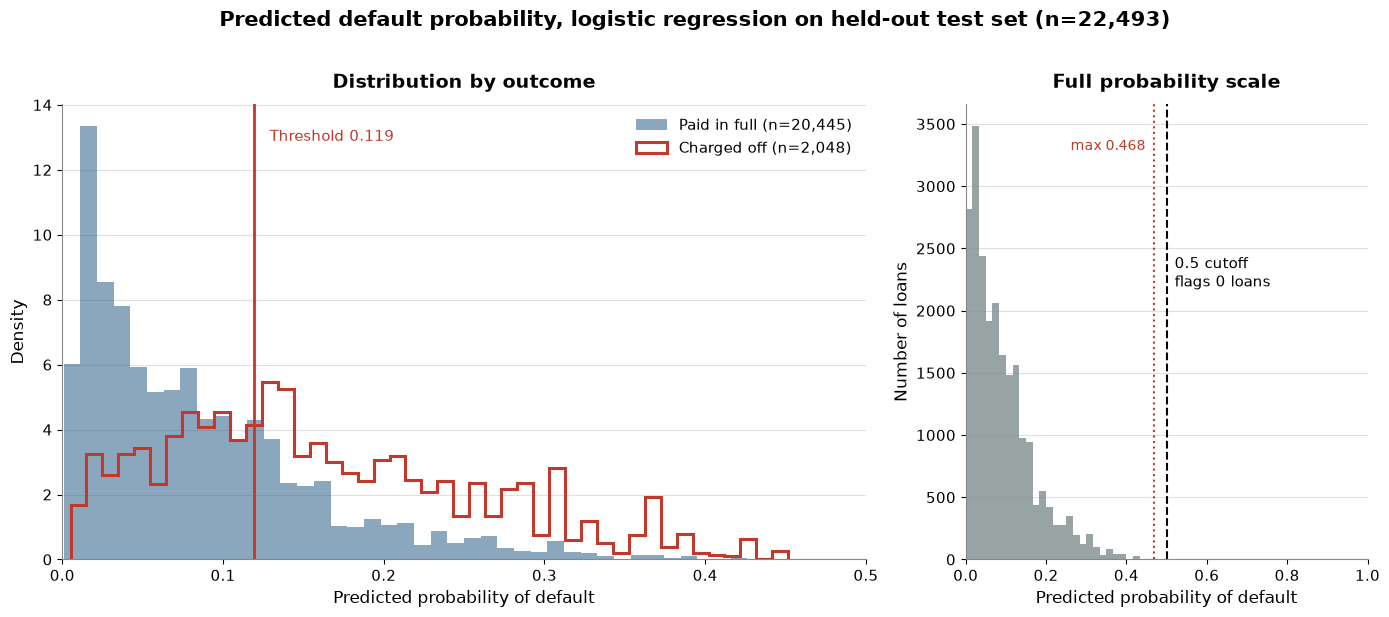

In [37]:
import matplotlib.pyplot as plt

# Splitting predicted probabilities by actual outcome for the left panel comparison
probs_defaulted = y_pred_proba[y_test == 1]
probs_repaid = y_pred_proba[y_test == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

# Shading paid-in-full loans as a backdrop and outlining charged-off loans as a step line, keeping both distributions readable without overlapping fills
ax1.hist(probs_repaid, bins=45, density=True, color='#2c5f8a', alpha=0.55,
         label=f'Paid in full (n={len(probs_repaid):,})', zorder=2)
ax1.hist(probs_defaulted, bins=45, density=True, histtype='step', linewidth=2.2,
         color='#c0392b', label=f'Charged off (n={len(probs_defaulted):,})', zorder=3)

# Marking the classification threshold used to convert probabilities into flagged loans
ax1.axvline(optimal_threshold, color='#c0392b', linewidth=2, zorder=4)
ax1.text(optimal_threshold + 0.01, ax1.get_ylim()[1] * 0.92, f'Threshold {optimal_threshold:.3f}',
          fontsize=11, color='#c0392b')

ax1.set_xlim(0, 0.5)
ax1.set_xlabel('Predicted probability of default', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution by outcome', fontsize=14, fontweight='bold', pad=12)
ax1.legend(loc='upper right', fontsize=11, frameon=False)
ax1.tick_params(labelsize=11)
ax1.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#888888')
ax1.spines['bottom'].set_color('#888888')

# Plotting the full 0-1 probability range to show how little of the scale the model actually uses
ax2.hist(y_pred_proba, bins=60, range=(0, 1), color='#7f8c8d', alpha=0.8)

# Marking the standard 0.5 cutoff alongside the model's actual maximum predicted probability
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
ax2.text(0.52, ax2.get_ylim()[1] * 0.6, '0.5 cutoff\nflags 0 loans', fontsize=11)
ax2.axvline(y_pred_proba.max(), color='#c0392b', linestyle=':', linewidth=1.5)
ax2.text(y_pred_proba.max() - 0.02, ax2.get_ylim()[1] * 0.9, f'max {y_pred_proba.max():.3f}',
          fontsize=10, ha='right', color='#c0392b')

ax2.set_xlim(0, 1)
ax2.set_xlabel('Predicted probability of default', fontsize=12)
ax2.set_ylabel('Number of loans', fontsize=12)
ax2.set_title('Full probability scale', fontsize=14, fontweight='bold', pad=12)
ax2.tick_params(labelsize=11)
ax2.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#888888')
ax2.spines['bottom'].set_color('#888888')

fig.suptitle('Predicted default probability, logistic regression on held-out test set (n=22,493)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Saving the figure for the report and rendering it in the notebook
plt.savefig('figures/nb03_fig03_predicted_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Seeing the KS statistic**

The KS number on its own doesn't show much. This plots the two cumulative curves it compares, how quickly the model accumulates defaulted loans against how quickly it accumulates repaid ones, with the widest gap between them marked.

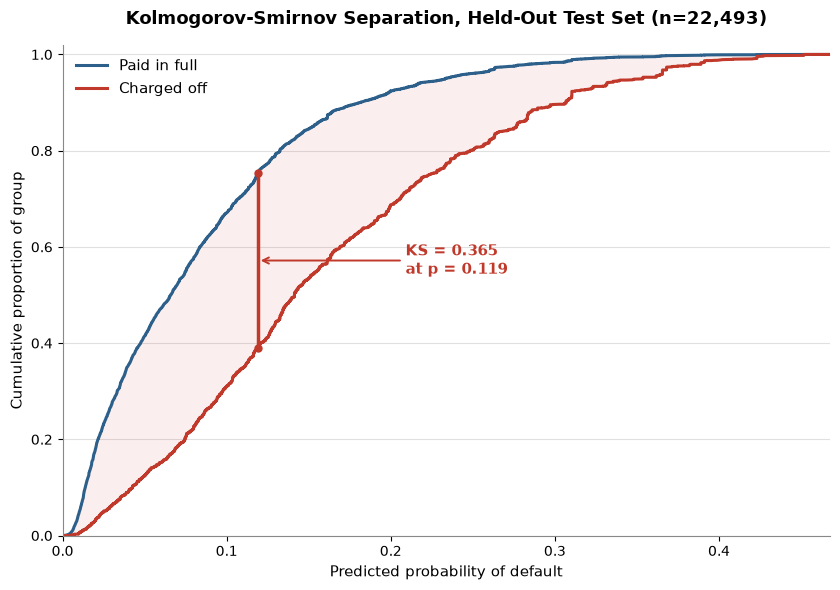

In [38]:
import numpy as np

# Sorting predictions and building cumulative curves for each outcome group
order = np.argsort(y_pred_proba)
sorted_probs = y_pred_proba[order]
sorted_actual = y_test.values[order]

cum_bad = np.cumsum(sorted_actual) / sorted_actual.sum()
cum_good = np.cumsum(1 - sorted_actual) / (1 - sorted_actual).sum()

# The KS statistic is the largest vertical gap between the two curves
gap = np.abs(cum_good - cum_bad)
ks_index = gap.argmax()
ks_x = sorted_probs[ks_index]

fig, ax = plt.subplots(figsize=(8.5, 6))

# Shading the gap between the curves so the separation reads as an area, not just two lines
ax.fill_between(sorted_probs, cum_bad, cum_good, color='#c0392b', alpha=0.08)

ax.plot(sorted_probs, cum_good, color='#2c5f8a', linewidth=2.2, label='Paid in full')
ax.plot(sorted_probs, cum_bad, color='#c0392b', linewidth=2.2, label='Charged off')

# Marking the point of maximum separation
ax.vlines(ks_x, cum_bad[ks_index], cum_good[ks_index], color='#c0392b', linewidth=2.5)
ax.plot([ks_x, ks_x], [cum_bad[ks_index], cum_good[ks_index]], 'o', color='#c0392b', markersize=5)
ax.annotate(f'KS = {ks_stat:.3f}\nat p = {ks_x:.3f}',
            xy=(ks_x, (cum_good[ks_index] + cum_bad[ks_index]) / 2),
            xytext=(ks_x + 0.09, (cum_good[ks_index] + cum_bad[ks_index]) / 2),
            fontsize=11, color='#c0392b', va='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.4))

ax.set_xlim(0, sorted_probs.max())
ax.set_ylim(0, 1.02)
ax.set_xlabel('Predicted probability of default', fontsize=11)
ax.set_ylabel('Cumulative proportion of group', fontsize=11)
ax.set_title('Kolmogorov-Smirnov Separation, Held-Out Test Set (n=22,493)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, frameon=False)
ax.tick_params(labelsize=10)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')
plt.tight_layout()

# Saving the figure for the report and rendering it in the notebook
plt.savefig('figures/nb03_fig05_ks_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### **Evaluation Summary Table**

In [39]:
# Bringing every metric together into one summary table 
evaluation_summary = pd.DataFrame({
    'Metric': ['ROC-AUC', 'KS Statistic', 'Gini Coefficient', 'Optimal Threshold', 'Precision', 'Recall'],
    'Value': [auc_score, ks_stat, gini, optimal_threshold, precision, recall]
})
evaluation_summary['Value'] = evaluation_summary['Value'].round(4)

evaluation_summary

,Metric,Value
0,ROC-AUC,0.7473
1,KS Statistic,0.3645
2,Gini Coefficient,0.4947
3,Optimal Threshold,0.1190
4,Precision,0.1990
5,Recall,0.6108


## **Stage 8: Gradient Boosting Comparison**

Testing whether a more flexible model meaningfully beats the interpretable baseline, using identical features and split so the comparison is fair.

In [40]:
from xgboost import XGBClassifier

# Ensuring both feature sets are plain float values, not a lingering categorical type from pd.cut()
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Creating the gradient boosting model
xgb_model = XGBClassifier(random_state=42)

# Fitting it on the same training data used for the logistic regression
xgb_model.fit(X_train, y_train)

# Generating predicted probabilities on the same test set
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost model fitted successfully")

XGBoost model fitted successfully


In [41]:
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Calculating ROC-AUC for the gradient boosting model
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

# Calculating KS for the gradient boosting model
xgb_probs_bad = xgb_pred_proba[y_test == 1]
xgb_probs_good = xgb_pred_proba[y_test == 0]
xgb_ks, _ = ks_2samp(xgb_probs_bad, xgb_probs_good)

# Calculating Gini for the gradient boosting model
xgb_gini = 2 * xgb_auc - 1

# Comparing both models side by side
comparison_table = pd.DataFrame({
    'Metric': ['ROC-AUC', 'KS Statistic', 'Gini Coefficient'],
    'Logistic Regression': [auc_score, ks_stat, gini],
    'Gradient Boosting': [xgb_auc, xgb_ks, xgb_gini]
})
comparison_table[['Logistic Regression', 'Gradient Boosting']] = comparison_table[['Logistic Regression', 'Gradient Boosting']].round(4)

comparison_table

,Metric,Logistic Regression,Gradient Boosting
0,ROC-AUC,0.7473,0.7614
1,KS Statistic,0.3645,0.3894
2,Gini Coefficient,0.4947,0.5229


**ROC curves for both models**

Both models on the same axes. The diagonal is what a model with no discriminatory power would produce, so the distance between each curve and that line is what the AUC number summarises. The two curves sit close together, which is the visual form of the 1.4-point AUC gap.

C:\Users\Muhammad Mubashar\AppData\Local\Temp\ipykernel_23964\611284704.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


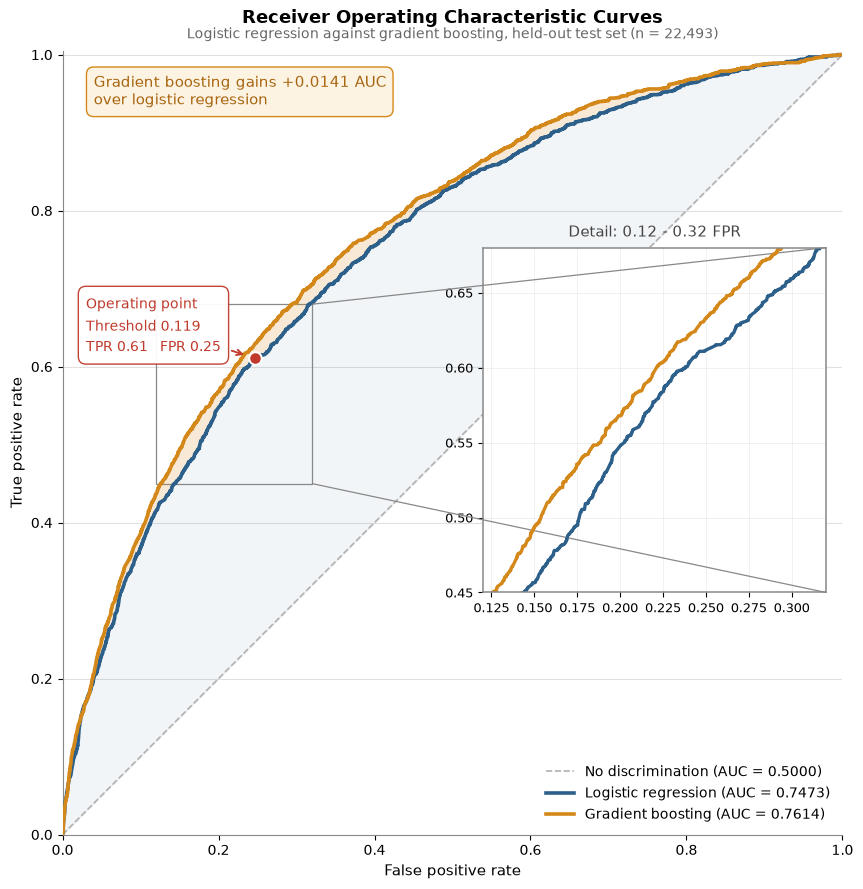

In [42]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Computing ROC curve points for both models, xgb_model was fitted in an earlier cell
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, y_pred_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)

# Interpolating both curves onto a shared grid so the gap between them can be shaded
common_fpr = np.linspace(0, 1, 500)
lr_interp = np.interp(common_fpr, lr_fpr, lr_tpr)
xgb_interp = np.interp(common_fpr, xgb_fpr, xgb_tpr)

fig, ax = plt.subplots(figsize=(9, 9))

# Shading the lift of logistic regression over random guessing
ax.fill_between(lr_fpr, lr_fpr, lr_tpr, color='#2c5f8a', alpha=0.06, zorder=1)

# Shading where gradient boosting pulls ahead of logistic regression, the actual case for switching models
better_mask = xgb_interp >= lr_interp
ax.fill_between(common_fpr, lr_interp, xgb_interp, where=better_mask,
                 color='#d4881a', alpha=0.18, interpolate=True, zorder=2)

ax.plot([0, 1], [0, 1], color='#b0b0b0', linestyle='--', linewidth=1.2, zorder=3,
        label='No discrimination (AUC = 0.5000)')
ax.plot(lr_fpr, lr_tpr, color='#2c5f8a', linewidth=2.6, zorder=4,
        label=f'Logistic regression (AUC = {auc_score:.4f})')
ax.plot(xgb_fpr, xgb_tpr, color='#d4881a', linewidth=2.6, zorder=5,
        label=f'Gradient boosting (AUC = {xgb_auc:.4f})')

# Reporting the AUC gain directly, so the reader doesn't have to subtract the legend values themselves
delta_auc = xgb_auc - auc_score
ax.text(0.04, 0.97, f'Gradient boosting gains {delta_auc:+.4f} AUC\nover logistic regression',
         transform=ax.transAxes, ha='left', va='top', fontsize=10.5, color='#a8650f',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdf3e3', edgecolor='#d4881a', linewidth=1.0))

# Locating where the classification threshold sits on the logistic regression curve, for marking below
threshold_idx = np.argmin(np.abs(lr_thresholds - optimal_threshold))
op_x, op_y = lr_fpr[threshold_idx], lr_tpr[threshold_idx]
ax.plot(op_x, op_y, 'o', color='#c0392b', markersize=9, zorder=7,
        markeredgecolor='white', markeredgewidth=1.4)
ax.annotate(f'Operating point\nThreshold {optimal_threshold:.3f}\nTPR {op_y:.2f}   FPR {op_x:.2f}',
            xy=(op_x, op_y), xytext=(0.03, 0.62),
            fontsize=10, color='#c0392b', linespacing=1.5, zorder=8,
            bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#c0392b', alpha=0.95, linewidth=1.0),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.3, shrinkB=8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.005)
ax.set_xlabel('False positive rate', fontsize=11)
ax.set_ylabel('True positive rate', fontsize=11)
ax.set_title('Receiver Operating Characteristic Curves', fontsize=13, pad=20, fontweight='bold')
ax.text(0.5, 1.016, 'Logistic regression against gradient boosting, held-out test set (n = 22,493)',
        transform=ax.transAxes, ha='center', fontsize=10, color='#666666')
ax.legend(loc='lower right', fontsize=10, frameon=False)
ax.tick_params(labelsize=10)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_aspect('equal')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

# Adding a zoomed-in panel on the region where the two curves actually separate, since it's hard to see at full scale
axins = inset_axes(ax, width='100%', height='100%', bbox_to_anchor=(0.53, 0.30, 0.44, 0.44),
                   bbox_transform=ax.transAxes, loc='lower left')
axins.plot(lr_fpr, lr_tpr, color='#2c5f8a', linewidth=2.4)
axins.plot(xgb_fpr, xgb_tpr, color='#d4881a', linewidth=2.4)
axins.set_xlim(0.12, 0.32)
axins.set_ylim(0.45, 0.68)
axins.grid(alpha=0.2, linewidth=0.6)
axins.set_axisbelow(True)
axins.tick_params(labelsize=9.5)
axins.set_title('Detail: 0.12 - 0.32 FPR', fontsize=10.5, pad=8, color='#444444')
for spine in axins.spines.values():
    spine.set_color('#888888')
    spine.set_linewidth(1.1)
mark_inset(ax, axins, loc1=1, loc2=4, fc='none', ec='#888888', lw=0.9)

plt.tight_layout()
plt.savefig('figures/nb03_fig04_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Muhammad Mubashar\AppData\Local\Temp\ipykernel_23964\2423009276.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


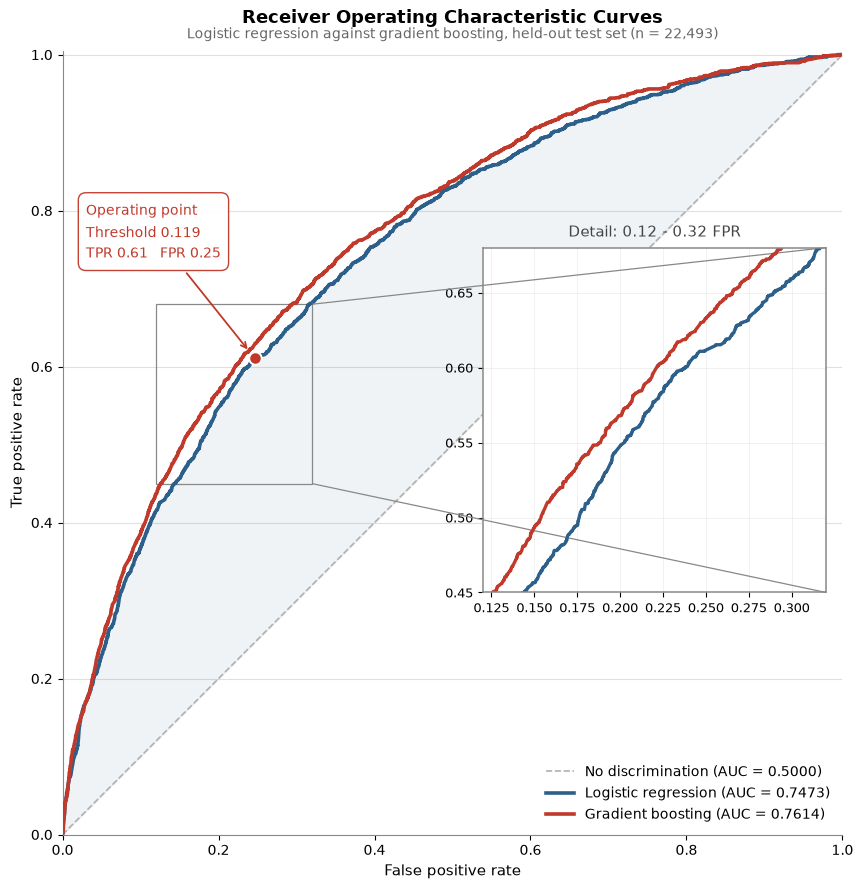

In [43]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Computing ROC curve points for both models, xgb_model was fitted in an earlier cell
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, y_pred_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)

fig, ax = plt.subplots(figsize=(9, 9))

# Shading the area between the logistic regression curve and the diagonal, so the lift over random guessing is visible
ax.fill_between(lr_fpr, lr_fpr, lr_tpr, color='#2c5f8a', alpha=0.07, zorder=1)

ax.plot([0, 1], [0, 1], color='#b0b0b0', linestyle='--', linewidth=1.2, zorder=2,
        label='No discrimination (AUC = 0.5000)')
ax.plot(lr_fpr, lr_tpr, color='#2c5f8a', linewidth=2.6, zorder=3,
        label=f'Logistic regression (AUC = {auc_score:.4f})')
ax.plot(xgb_fpr, xgb_tpr, color='#c0392b', linewidth=2.6, zorder=4,
        label=f'Gradient boosting (AUC = {xgb_auc:.4f})')

# Locating where the classification threshold sits on the logistic regression curve, for marking below
threshold_idx = np.argmin(np.abs(lr_thresholds - optimal_threshold))
op_x, op_y = lr_fpr[threshold_idx], lr_tpr[threshold_idx]
ax.plot(op_x, op_y, 'o', color='#c0392b', markersize=9, zorder=7,
        markeredgecolor='white', markeredgewidth=1.4)
ax.annotate(f'Operating point\nThreshold {optimal_threshold:.3f}\nTPR {op_y:.2f}   FPR {op_x:.2f}',
            xy=(op_x, op_y), xytext=(0.03, 0.74),
            fontsize=10, color='#c0392b', linespacing=1.5, zorder=8,
            bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#c0392b', alpha=0.95, linewidth=1.0),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.3, shrinkB=8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.005)
ax.set_xlabel('False positive rate', fontsize=11)
ax.set_ylabel('True positive rate', fontsize=11)
ax.set_title('Receiver Operating Characteristic Curves', fontsize=13, pad=20, fontweight='bold')
ax.text(0.5, 1.016, 'Logistic regression against gradient boosting, held-out test set (n = 22,493)',
        transform=ax.transAxes, ha='center', fontsize=10, color='#666666')
ax.legend(loc='lower right', fontsize=10, frameon=False)
ax.tick_params(labelsize=10)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_aspect('equal')

# Dropping the top and right borders since they're not carrying any information
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

# Adding a zoomed-in panel on the region where the two curves actually separate, since it's hard to see at full scale
axins = inset_axes(ax, width='100%', height='100%', bbox_to_anchor=(0.53, 0.30, 0.44, 0.44),
                   bbox_transform=ax.transAxes, loc='lower left')
axins.plot(lr_fpr, lr_tpr, color='#2c5f8a', linewidth=2.4)
axins.plot(xgb_fpr, xgb_tpr, color='#c0392b', linewidth=2.4)
axins.set_xlim(0.12, 0.32)
axins.set_ylim(0.45, 0.68)
axins.grid(alpha=0.2, linewidth=0.6)
axins.set_axisbelow(True)
axins.tick_params(labelsize=9.5)
axins.set_title('Detail: 0.12 - 0.32 FPR', fontsize=10.5, pad=8, color='#444444')
for spine in axins.spines.values():
    spine.set_color('#888888')
    spine.set_linewidth(1.1)
mark_inset(ax, axins, loc1=1, loc2=4, fc='none', ec='#888888', lw=0.9)

plt.tight_layout()
plt.savefig('figures/nb03_fig04_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Muhammad Mubashar\AppData\Local\Temp\ipykernel_23964\80674244.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
findfont: Failed to find font weight semibold, now using 700.


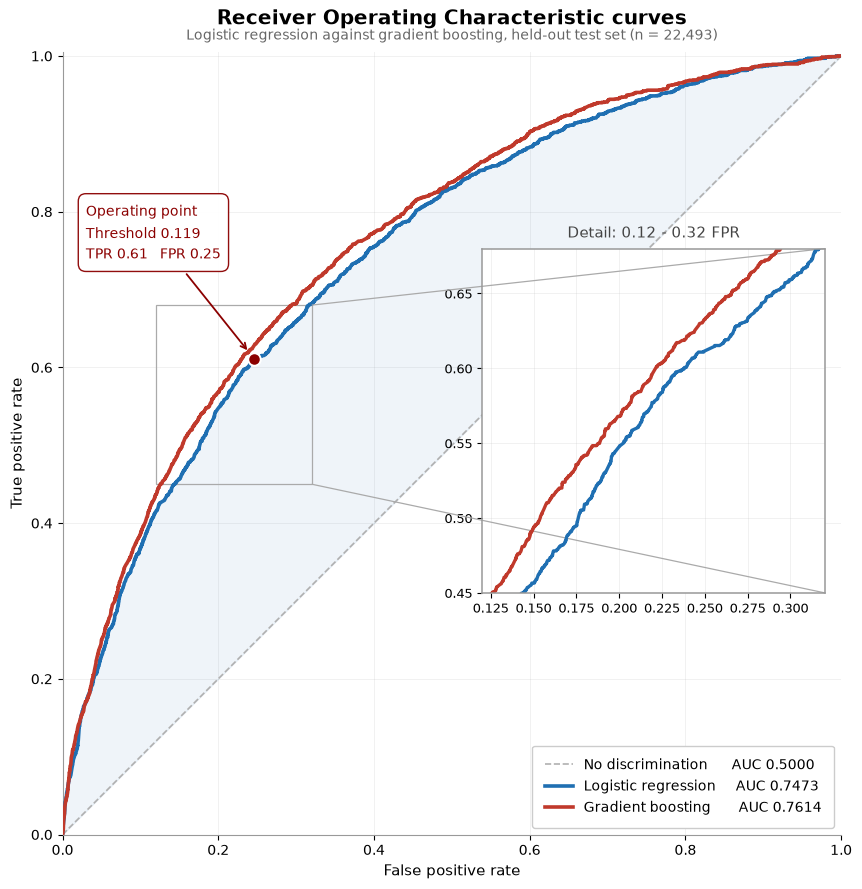

In [44]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Getting the ROC curve points for both models - xgb_model was already fitted above, so I'm just reusing it
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, y_pred_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)

fig, ax = plt.subplots(figsize=(9, 9))

# Shading the area between the logistic regression curve and the diagonal, so the lift over random guessing is visible
ax.fill_between(lr_fpr, lr_fpr, lr_tpr, color='#1f6fb2', alpha=0.07, zorder=1)

ax.plot([0, 1], [0, 1], color='#b0b0b0', linestyle='--', linewidth=1.2, zorder=2,
        label='No discrimination      AUC 0.5000')
ax.plot(lr_fpr, lr_tpr, color='#1f6fb2', linewidth=2.6, zorder=3,
        label=f'Logistic regression     AUC {auc_score:.4f}')
ax.plot(xgb_fpr, xgb_tpr, color='#c0392b', linewidth=2.6, zorder=4,
        label=f'Gradient boosting       AUC {xgb_auc:.4f}')

# Finding where my chosen threshold actually sits on the logistic regression curve, so I can mark it
threshold_idx = np.argmin(np.abs(lr_thresholds - optimal_threshold))
op_x, op_y = lr_fpr[threshold_idx], lr_tpr[threshold_idx]
ax.plot(op_x, op_y, 'o', color='#8b0000', markersize=9, zorder=7,
        markeredgecolor='white', markeredgewidth=1.4)
ax.annotate(f'Operating point\nThreshold {optimal_threshold:.3f}\nTPR {op_y:.2f}   FPR {op_x:.2f}',
            xy=(op_x, op_y), xytext=(0.03, 0.74),
            fontsize=10, color='#8b0000', linespacing=1.5, zorder=8,
            bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='#8b0000', alpha=0.95, linewidth=1.0),
            arrowprops=dict(arrowstyle='->', color='#8b0000', lw=1.3, shrinkB=8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.005)
ax.set_xlabel('False positive rate', fontsize=11)
ax.set_ylabel('True positive rate', fontsize=11)
ax.set_title('Receiver Operating Characteristic curves', fontsize=14.5, pad=20, fontweight='semibold')
ax.text(0.5, 1.016, 'Logistic regression against gradient boosting, held-out test set (n = 22,493)',
        transform=ax.transAxes, ha='center', fontsize=10, color='#666666')
ax.legend(loc='lower right', fontsize=10, framealpha=1.0, edgecolor='#cccccc', borderpad=0.9)
ax.grid(alpha=0.18, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_aspect('equal')

# Dropping the top and right borders since they're not carrying any information
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999999')
ax.spines['bottom'].set_color('#999999')

# Adding a zoomed-in panel on the region where the two curves actually separate, since it's hard to see at full scale
axins = inset_axes(ax, width='100%', height='100%', bbox_to_anchor=(0.53, 0.30, 0.44, 0.44),
                   bbox_transform=ax.transAxes, loc='lower left')
axins.plot(lr_fpr, lr_tpr, color='#1f6fb2', linewidth=2.4)
axins.plot(xgb_fpr, xgb_tpr, color='#c0392b', linewidth=2.4)
axins.set_xlim(0.12, 0.32)
axins.set_ylim(0.45, 0.68)
axins.grid(alpha=0.2, linewidth=0.6)
axins.set_axisbelow(True)
axins.tick_params(labelsize=9.5)
axins.set_title('Detail: 0.12 - 0.32 FPR', fontsize=10.5, pad=8, color='#444444')
for spine in axins.spines.values():
    spine.set_color('#999999')
    spine.set_linewidth(1.1)
mark_inset(ax, axins, loc1=1, loc2=4, fc='none', ec='#aaaaaa', lw=0.9)

plt.tight_layout()
plt.savefig('figures/nb03_fig04_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
# Checking how much weight XGBoost gave each variable when making its decisions
xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_importance

,Feature,Importance
0,LoanSize_WoE,0.572721
3,BorrState_WoE,0.195798
1,BusinessAge_WoE,0.133160
2,NaicsSector_WoE,0.098320


## **Stage 9: Scorecard and Expected Loss**

Turning the model into an actual business tool: a real loss rate calculated from what SBA recorded on defaulted loans, and a points-based score built from it.

In [46]:
# Calculating Loss Given Default (LGD) from observed charge-off amounts

# Working out what fraction of the approved loan amount was actually lost, for every loan
model_df['LGD'] = model_df['GrossChargeOffAmount'] / model_df['GrossApproval']

# Looking only at loans that actually charged off, since LGD has no meaning for loans that didn't default
chgoff_lgd = model_df[model_df['default'] == 1]['LGD']

chgoff_lgd.describe()

count    6826.000000
mean        0.864578
std         0.327905
min         0.000000
25%         0.790413
50%         0.937912
75%         0.990981
max        19.474107
Name: LGD, dtype: float64

In [47]:
# Capping LGD at 100%, since a loan cannot logically lose more than its full exposure
model_df['LGD'] = model_df['LGD'].clip(upper=1.0)

# Confirming the cap worked, the new maximum should now be exactly 1.0
model_df[model_df['default'] == 1]['LGD'].describe()

count    6826.000000
mean        0.851453
std         0.199181
min         0.000000
25%         0.790413
50%         0.937912
75%         0.990981
max         1.000000
Name: LGD, dtype: float64

In [48]:
# EAD is simply the original approved loan amount, since these are standard term loans disbursed upfront
model_df['EAD'] = model_df['GrossApproval']

In [49]:
# Getting the model's predicted probability of default for every loan in the full dataset
model_df['PD'] = log_reg.predict_proba(model_df[feature_cols].astype(float))[:, 1]

In [50]:
# LGD for expected loss: actual observed LGD where a loan defaulted, average LGD otherwise
average_lgd = model_df[model_df['default'] == 1]['LGD'].mean()
model_df['LGD_for_EL'] = np.where(model_df['default'] == 1, model_df['LGD'], average_lgd)

In [51]:
# Expected Loss = Probability of Default (pd) x Loss Given Default (lgd) x Exposure at Default (EaD)
model_df['ExpectedLoss'] = model_df['PD'] * model_df['LGD_for_EL'] * model_df['EAD']

model_df[['default', 'PD', 'LGD_for_EL', 'EAD', 'ExpectedLoss']].head()

,default,PD,LGD_for_EL,EAD,ExpectedLoss
0,0,0.137780,0.851453,25000.0,2932.832022
1,0,0.233237,0.851453,95800.0,19024.991746
2,0,0.144393,0.851453,40000.0,4917.764622
3,0,0.063523,0.851453,250000.0,13521.629839
4,0,0.144220,0.851453,100000.0,12279.693226


LGD sensitivity: whose loss are we measuring?

In [52]:
# Checking the guarantee amount field before using it
model_df['SBAGuaranteedApproval'].describe()

count    7.497600e+04
mean     3.898022e+05
std      6.921278e+05
min      5.000000e+02
25%      2.500000e+04
50%      1.218750e+05
75%      3.810000e+05
max      4.500000e+06
Name: SBAGuaranteedApproval, dtype: float64

In [53]:
# Guarantee rate as a share of the approved amount
model_df['GuaranteeRate'] = model_df['SBAGuaranteedApproval'] / model_df['GrossApproval']

# Checking how the guarantee rate varies across loan size bands
guarantee_by_size = model_df.groupby('LoanSizeBand', observed=True).agg(
    mean_guarantee_rate=('GuaranteeRate', 'mean'),
    loan_count=('GuaranteeRate', 'count')
)
guarantee_by_size['mean_guarantee_rate'] = (guarantee_by_size['mean_guarantee_rate'] * 100).round(1)

print(f"Overall mean guarantee rate: {model_df['GuaranteeRate'].mean() * 100:.1f}%")
print(f"Mean guarantee rate on charged-off loans: {model_df[model_df['default'] == 1]['GuaranteeRate'].mean() * 100:.1f}%")
print()
guarantee_by_size

Overall mean guarantee rate: 67.7%
Mean guarantee rate on charged-off loans: 63.8%



,mean_guarantee_rate,loan_count
LoanSizeBand,,
Under $50k,56.4,21763
$50k-$150k,67.2,16256
$150k-$350k,69.1,13445
$350k-$1M,76.0,13009
Over $1M,79.4,10503


In [54]:
# Working out how the observed facility loss splits between SBA and the lender
mean_facility_lgd = model_df[model_df['default'] == 1]['LGD'].mean()
mean_guarantee_on_defaults = model_df[model_df['default'] == 1]['GuaranteeRate'].mean()

sba_borne_lgd = mean_facility_lgd * mean_guarantee_on_defaults
lender_retained_lgd = mean_facility_lgd * (1 - mean_guarantee_on_defaults)

# The five LGD definitions I want to compare, including two common textbook assumptions
lgd_definitions = {
    'Whole facility (observed average)': mean_facility_lgd,
    'SBA-borne (guarantee-implied)': sba_borne_lgd,
    'Lender-retained': lender_retained_lgd,
    'Textbook assumption: total loss': 1.00,
    'Textbook assumption: 75% loss': 0.75
}

# Recalculating total expected loss under each one, keeping PD and EAD exactly the same throughout
sensitivity = []
for label, lgd_value in lgd_definitions.items():
    total_el = (model_df['PD'] * lgd_value * model_df['EAD']).sum()
    sensitivity.append({
        'LGD Definition': label,
        'LGD': round(lgd_value, 4),
        'Total Expected Loss ($M)': round(total_el / 1_000_000, 1)
    })

lgd_sensitivity = pd.DataFrame(sensitivity)
lgd_sensitivity

,LGD Definition,LGD,Total Expected Loss ($M)
0,Whole facility (observed average),0.8515,999.1
1,SBA-borne (guarantee-implied),0.5430,637.2
2,Lender-retained,0.3085,362.0
3,Textbook assumption: total loss,1.0000,1173.4
4,Textbook assumption: 75% loss,0.7500,880.1


In [55]:
# Setting up two fixed numbers the scorecard formula needs: how many points = risk cut in half (PDO),
# and where the scale should sit (baseline score at a baseline odds level)

PDO = 50            # 50 points = odds of default cut in half, a standard industry convention
baseline_score = 600
baseline_odds = 1   # 1:1 odds = 50% probability, used as the reference point for the scale

Factor = PDO / np.log(2)
Offset = baseline_score - Factor * np.log(baseline_odds)

print(f"Factor: {Factor:.2f}")
print(f"Offset: {Offset:.2f}")

Factor: 72.13
Offset: 600.00


**The scorecard**

Factor and Offset set the scale, but a scorecard is really a lookup table: how many points a loan earns for each characteristic. This converts the model's coefficients and WoE values into those points, so a score can be read off directly.

In [56]:
# Points contributed by each attribute, derived from its WoE and the model coefficient for that variable
n_features = len(feature_cols)
intercept = log_reg.intercept_[0]

source_map = {
    'LoanSize_WoE': 'LoanSizeBand',
    'BusinessAge_WoE': 'BusinessAge',
    'NaicsSector_WoE': 'NaicsSectorGrouped',
    'BorrState_WoE': 'BorrStateGrouped'
}

points_rows = []
for i, feature in enumerate(feature_cols):
    coef = log_reg.coef_[0][i]
    source_col = source_map[feature]
    woe_map = calculate_woe_map(model_df, source_col)

    for attribute, woe in woe_map.items():
        points = -(coef * woe + intercept / n_features) * Factor + Offset / n_features
        points_rows.append({
            'Variable': source_col,
            'Attribute': str(attribute),
            'WoE': round(woe, 4),
            'Points': round(points, 1)
        })

scorecard_points = pd.DataFrame(points_rows).sort_values(['Variable', 'Points'], ascending=[True, False])

# How far each variable can move a score, from its lowest-scoring attribute to its highest
points_spread = scorecard_points.groupby('Variable')['Points'].agg(
    min_points='min', max_points='max', attributes='count'
)
points_spread['spread'] = (points_spread['max_points'] - points_spread['min_points']).round(1)
points_spread = points_spread.sort_values('spread', ascending=False)

points_spread

,min_points,max_points,attributes,spread
Variable,,,,
BorrStateGrouped,97.8,373.9,53,276.1
LoanSizeBand,150.7,318.1,5,167.4
NaicsSectorGrouped,162.6,297.8,23,135.2
BusinessAge,175.3,217.5,5,42.2


In [57]:
# Calculating odds of being good (non-default)
model_df['Odds'] = (1 - model_df['PD']) / model_df['PD']

# Converting odds into a credit score using the scale factor and offset
model_df['CreditScore'] = Offset + Factor * np.log(model_df['Odds'])

# Selecting the first five rows for display
score_check = model_df[['PD', 'Odds', 'CreditScore']].head().copy()

# Converting probability to a percentage and rounding all columns
score_check['PD'] = (score_check['PD'] * 100).round(1)
score_check['Odds'] = score_check['Odds'].round(2)
score_check['CreditScore'] = score_check['CreditScore'].round(0)

# Renaming columns to plain labels
score_check.columns = ['Default Probability (%)', 'Odds of Being Good', 'Credit Score']

score_check

,Default Probability (%),Odds of Being Good,Credit Score
0,13.8,6.26,732.0
1,23.3,3.29,686.0
2,14.4,5.93,728.0
3,6.4,14.74,794.0
4,14.4,5.93,728.0


In [58]:
# Listing the attribute labels for each scorecard variable, since the points
# table keys on the exact string
for v in ['LoanSizeBand', 'BusinessAge', 'NaicsSectorGrouped', 'BorrStateGrouped']:
    print(v, '->', sorted(model_df[v].astype(str).unique())[:8], '\n')

LoanSizeBand -> ['$150k-$350k', '$350k-$1M', '$50k-$150k', 'Over $1M', 'Under $50k'] 

BusinessAge -> ['Change of Ownership', 'Existing or more than 2 years old', 'New Business or 2 years or less', 'Startup, Loan Funds will Open Business', 'Unanswered'] 

NaicsSectorGrouped -> ['11', '21', '22', '23', '31', '32', '33', '42'] 

BorrStateGrouped -> ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC'] 



In [59]:
# Listing every scorecard attribute with its points, grouped by variable
for var in scorecard_points['Variable'].unique():
    rows = scorecard_points.query("Variable == @var")[['Attribute', 'Points']]

    # State has 53 attributes, so showing only the ones needed for the examples
    if var == 'BorrStateGrouped':
        rows = rows[rows['Attribute'].isin(['NY', 'CA', 'TX', 'MN', 'WI', 'IA', 'NE'])]
        print(f"--- {var} (filtered, {len(scorecard_points.query('Variable == @var'))} total) ---")
    else:
        print(f"--- {var} ---")

    print(rows.to_string(index=False))
    print()

--- BorrStateGrouped (filtered, 53 total) ---
Attribute  Points
       NE   268.7
       MN   236.3
       IA   231.4
       WI   229.2
       CA   185.6
       TX   178.4
       NY   125.4

--- BusinessAge ---
                             Attribute  Points
                   Change of Ownership   217.5
                            Unanswered   202.9
     Existing or more than 2 years old   193.9
Startup, Loan Funds will Open Business   189.9
       New Business or 2 years or less   175.3

--- LoanSizeBand ---
  Attribute  Points
   Over $1M   318.1
  $350k-$1M   271.5
$150k-$350k   213.6
 $50k-$150k   167.4
 Under $50k   150.7

--- NaicsSectorGrouped ---
Attribute  Points
       21   297.8
    Other   280.7
       11   235.7
       32   221.7
       52   220.5
       62   216.5
       33   214.0
       31   204.6
       44   199.4
       72   199.2
       53   193.9
       81   192.1
       56   189.1
       23   188.8
       54   187.6
       51   186.5
       61   184.9
       71   1

In [60]:
# Running two example loans through the scorecard, from attribute points to expected loss
examples = {
    'Restaurant, NY, under 2 years, $75k': (
        {'LoanSizeBand': '$50k-$150k',
         'BusinessAge': 'New Business or 2 years or less',
         'NaicsSectorGrouped': '72',
         'BorrStateGrouped': 'NY'}, 75_000),

    'Manufacturer, MN, established, $1.5M': (
        {'LoanSizeBand': 'Over $1M',
         'BusinessAge': 'Existing or more than 2 years old',
         'NaicsSectorGrouped': '33',
         'BorrStateGrouped': 'MN'}, 1_500_000),
}

band_edges = [0, 650, 700, 725, 750, 775, 2000]
band_labels = ['Below 650', '650-700', '700-725', '725-750', '750-775', 'Above 775']

# Building bands here too, so this cell doesn't depend on the later "Score bands" section having run first
score_bands = pd.cut(model_df['CreditScore'], bins=band_edges, labels=band_labels)
bands = model_df.groupby(score_bands, observed=True).agg(
    loans=('default', 'count'),
    observed_default_rate=('default', 'mean'),
    total_exposure=('GrossApproval', 'sum')
)
bands['observed_default_rate'] = (bands['observed_default_rate'] * 100).round(2)
bands['share_of_loans'] = (bands['loans'] / bands['loans'].sum() * 100).round(1)
bands['share_of_exposure'] = (bands['total_exposure'] / bands['total_exposure'].sum() * 100).round(1)
bands = bands[['loans', 'share_of_loans', 'observed_default_rate', 'share_of_exposure']]
bands.columns = ['Loans', 'Share of loans (%)', 'Observed default rate (%)', 'Share of exposure (%)']

breakdown, summary = [], []

for name, (profile, ead) in examples.items():
    score = 0
    for var, attr in profile.items():
        pts = scorecard_points.query("Variable == @var and Attribute == @attr")['Points'].iloc[0]
        breakdown.append({'Loan': name, 'Variable': var, 'Attribute': attr, 'Points': pts})
        score += pts

    # Inverting the score formula back to a default probability
    pd_est = 1 / (1 + np.exp((score - Offset) / Factor))
    band = pd.cut([score], bins=band_edges, labels=band_labels)[0]

    summary.append({
        'Loan': name,
        'Score': round(score, 1),
        'Band': band,
        'Predicted default rate (%)': round(pd_est * 100, 2),
        'Observed rate in band (%)': bands.loc[band, 'Observed default rate (%)'],
        'Exposure ($)': ead,
        'Expected loss ($)': round(pd_est * 0.8515 * ead)
    })

breakdown_table = pd.DataFrame(breakdown).pivot(
    index=['Variable', 'Attribute'], columns='Loan', values='Points')

summary_table = pd.DataFrame(summary).set_index('Loan').T

In [61]:
# Where each loan's points come from
breakdown_table

Loan                                                  Manufacturer, MN, established, $1.5M  \
Variable           Attribute                                                                 
BorrStateGrouped   MN                                                                236.3   
                   NY                                                                  NaN   
BusinessAge        Existing or more than 2 years old                                 193.9   
                   New Business or 2 years or less                                     NaN   
LoanSizeBand       $50k-$150k                                                          NaN   
                   Over $1M                                                          318.1   
NaicsSectorGrouped 33                                                                214.0   
                   72                                                                  NaN   

Loan                                                  Restaurant, NY, under 2 years, $75k  
Variable           Attribute                                                               
BorrStateGrouped   MN                                                                 NaN  
                   NY                                                               125.4  
BusinessAge        Existing or more than 2 years old                                  NaN  
                   New Business or 2 years or less                                  175.3  
LoanSizeBand       $50k-$150k                                                       167.4  
                   Over $1M                                                           NaN  
NaicsSectorGrouped 33                                                                 NaN  
                   72                                                               199.2

In [62]:
# What those points translate into
summary_table

Loan,"Restaurant, NY, under 2 years, $75k","Manufacturer, MN, established, $1.5M"
Score,667.3,962.3
Band,650-700,Above 775
Predicted default rate (%),28.23,0.65
Observed rate in band (%),26.85,3.78
Exposure ($),75000,1500000
Expected loss ($),18030,8359


**Score bands**

Grouping loans into score ranges shows whether the scorecard separates risk in practice, and where the dollar exposure actually sits.

In [63]:
# Grouping loans into score bands and checking observed default rate and dollar exposure in each
score_bands = pd.cut(model_df['CreditScore'], bins=[0, 650, 700, 725, 750, 775, 2000],
                     labels=['Below 650', '650-700', '700-725', '725-750', '750-775', 'Above 775'])

bands = model_df.groupby(score_bands, observed=True).agg(
    loans=('default', 'count'),
    observed_default_rate=('default', 'mean'),
    total_exposure=('GrossApproval', 'sum')
)

bands['observed_default_rate'] = (bands['observed_default_rate'] * 100).round(2)
bands['share_of_loans'] = (bands['loans'] / bands['loans'].sum() * 100).round(1)
bands['share_of_exposure'] = (bands['total_exposure'] / bands['total_exposure'].sum() * 100).round(1)

bands = bands[['loans', 'share_of_loans', 'observed_default_rate', 'share_of_exposure']]
bands.columns = ['Loans', 'Share of loans (%)', 'Observed default rate (%)', 'Share of exposure (%)']

bands

,Loans,Share of loans (%),Observed default rate (%),Share of exposure (%)
CreditScore,,,,
Below 650,793,1.1,42.88,0.1
650-700,6515,8.7,26.85,0.9
700-725,6482,8.6,17.08,1.2
725-750,10231,13.6,11.70,2.3
750-775,9772,13.0,8.98,2.7
Above 775,41183,54.9,3.78,92.8


Translating the model into an actual lending decision: what total expected loss results from approving progressively more of the risk-ranked population.

In [64]:
# Sorting loans from safest to riskiest, using a stable sort so tied PD values keep a fixed order
sorted_loans = model_df.sort_values('PD', kind='mergesort').reset_index(drop=True)

# Approval rates to test, from 10% up to 100% in 5-point steps
approval_rates = np.arange(0.1, 1.01, 0.05)

results = []
for rate in approval_rates:
    # Taking the safest loans up to this cutoff point
    cutoff_index = int(len(sorted_loans) * rate)
    approved_loans = sorted_loans.iloc[:cutoff_index]

    total_expected_loss = approved_loans['ExpectedLoss'].sum()

    results.append({'ApprovalRate': rate, 'TotalExpectedLoss': total_expected_loss})

approval_loss_curve = pd.DataFrame(results)
approval_loss_curve

,ApprovalRate,TotalExpectedLoss
0,0.10,1.187630e+08
1,0.15,2.004672e+08
2,0.20,2.804685e+08
3,0.25,3.489294e+08
4,0.30,4.242925e+08
5,0.35,4.877429e+08
6,0.40,5.356325e+08
7,0.45,5.860891e+08
8,0.50,6.275665e+08
9,0.55,6.701885e+08


In [65]:
# Share of total expected loss falling in each score band
el_by_band = model_df.groupby(score_bands, observed=True)['ExpectedLoss'].sum()

el_share = pd.DataFrame({
    'Expected loss ($M)': (el_by_band / 1e6).round(1),
    'Share of expected loss (%)': (el_by_band / el_by_band.sum() * 100).round(1),
    'Share of exposure (%)': bands['Share of exposure (%)'],
    'Observed default rate (%)': bands['Observed default rate (%)']
})

el_share

,Expected loss ($M),Share of expected loss (%),Share of exposure (%),Observed default rate (%)
CreditScore,,,,
Below 650,8.6,0.9,0.1,42.88
650-700,75.6,7.6,0.9,26.85
700-725,66.5,6.7,1.2,17.08
725-750,95.4,9.6,2.3,11.70
750-775,82.4,8.3,2.7,8.98
Above 775,669.9,67.1,92.8,3.78


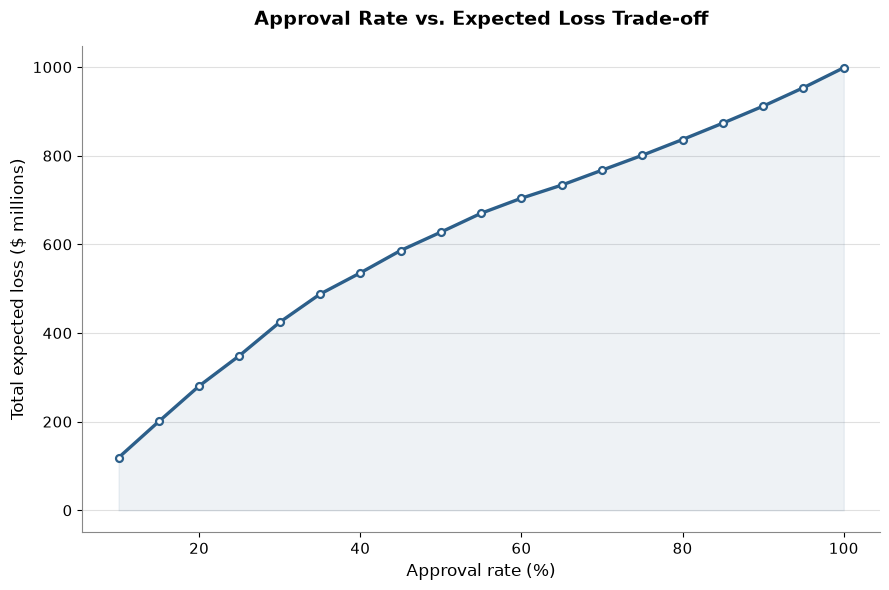

In [66]:
import matplotlib.pyplot as plt

approval_pct = approval_loss_curve['ApprovalRate'] * 100
loss_millions = approval_loss_curve['TotalExpectedLoss'] / 1_000_000

fig, ax = plt.subplots(figsize=(9, 6))

# Filling beneath the curve so the growing loss reads as an accumulating quantity, not just a line
ax.fill_between(approval_pct, loss_millions, color='#2c5f8a', alpha=0.08, zorder=1)
ax.plot(approval_pct, loss_millions, color='#2c5f8a', linewidth=2.4, marker='o', markersize=5,
        markerfacecolor='white', markeredgewidth=1.6, zorder=3)

ax.set_xlabel('Approval rate (%)', fontsize=12)
ax.set_ylabel('Total expected loss ($ millions)', fontsize=12)
ax.set_title('Approval Rate vs. Expected Loss Trade-off', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(labelsize=11)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

plt.tight_layout()

# Saving the figure for the report and rendering it in the notebook
plt.savefig('figures/nb03_fig01_approval_rate_vs_expected_loss.png', dpi=150, bbox_inches='tight')
plt.show()

The cumulative curve above rises steadily, but that hides more than it shows. Checking the cost of each additional slice of approvals separately.

In [67]:
# Marginal expected loss added per percentage point of approval rate
approval_loss_curve['MarginalCostPerPoint'] = (
    approval_loss_curve['TotalExpectedLoss'].diff() / (approval_loss_curve['ApprovalRate'].diff() * 100)
)

# Formatting a display copy: approval rate as a percentage, dollar figures in millions
marginal_table = approval_loss_curve.copy()
marginal_table['ApprovalRate'] = (marginal_table['ApprovalRate'] * 100).round(0)
marginal_table['TotalExpectedLoss'] = (marginal_table['TotalExpectedLoss'] / 1_000_000).round(1)
marginal_table['MarginalCostPerPoint'] = (marginal_table['MarginalCostPerPoint'] / 1_000_000).round(2)
marginal_table.columns = ['Approval Rate (%)', 'Total Expected Loss ($M)', 'Marginal Cost per Point ($M)']

marginal_table

,Approval Rate (%),Total Expected Loss ($M),Marginal Cost per Point ($M)
0,10.0,118.8,NaN
1,15.0,200.5,16.34
2,20.0,280.5,16.00
3,25.0,348.9,13.69
4,30.0,424.3,15.07
5,35.0,487.7,12.69
6,40.0,535.6,9.58
7,45.0,586.1,10.09
8,50.0,627.6,8.30
9,55.0,670.2,8.52


In [68]:
print(approval_loss_curve.columns.tolist())

['ApprovalRate', 'TotalExpectedLoss', 'MarginalCostPerPoint']


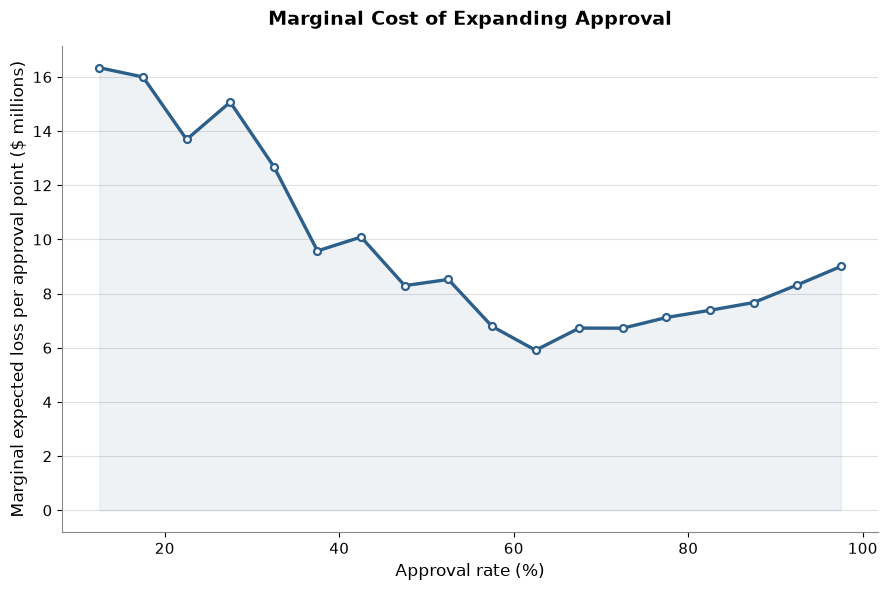

In [69]:
import numpy as np

approval_pct = (approval_loss_curve['ApprovalRate'] * 100).to_numpy()
loss_millions = (approval_loss_curve['TotalExpectedLoss'] / 1_000_000).to_numpy()

# Computing marginal cost as the change in total loss between consecutive approval-rate steps, since the dataframe only stores the running total
marginal_cost = np.diff(loss_millions) / np.diff(approval_pct)
approval_mid = (approval_pct[:-1] + approval_pct[1:]) / 2

fig, ax = plt.subplots(figsize=(9, 6))

ax.fill_between(approval_mid, marginal_cost, color='#2c5f8a', alpha=0.08, zorder=1)
ax.plot(approval_mid, marginal_cost, color='#2c5f8a', linewidth=2.4, marker='o', markersize=5,
        markerfacecolor='white', markeredgewidth=1.6, zorder=3)

ax.set_xlabel('Approval rate (%)', fontsize=12)
ax.set_ylabel('Marginal expected loss per approval point ($ millions)', fontsize=12)
ax.set_title('Marginal Cost of Expanding Approval', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(labelsize=11)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

plt.tight_layout()

plt.savefig('figures/nb03_fig02_marginal_cost_per_approval_point.png', dpi=300, bbox_inches='tight')
plt.show()

## **Stage 10: Temporal Validation**

Training a fresh model on pre-2022 loans only, then testing it on 2022-onward loans it never saw, to check whether the relationships learned before the rate environment shifted still hold.

In [70]:
# Making sure ApprovalDate is a real date type in this notebook session
model_df['ApprovalDate'] = pd.to_datetime(model_df['ApprovalDate'])

# Splitting loans into pre-2022 and 2022-onward groups, and counting each
pre_2022 = model_df[model_df['ApprovalDate'] < '2022-01-01']
post_2022 = model_df[model_df['ApprovalDate'] >= '2022-01-01']

print(f"Pre-2022 loans: {len(pre_2022)}")
print(f"2022-onward loans: {len(post_2022)}")

Pre-2022 loans: 46606
2022-onward loans: 28370


In [71]:
# I'm training a completely fresh model here, using only loans approved before 2022
X_pre = pre_2022[feature_cols].astype(float)
y_pre = pre_2022['default']

temporal_model = LogisticRegression()
temporal_model.fit(X_pre, y_pre)

# Now I'm testing that same model on loans from 2022 onward, which it has never seen before
X_post = post_2022[feature_cols].astype(float)
y_post = post_2022['default']

post_2022_pred_proba = temporal_model.predict_proba(X_post)[:, 1]

print("Temporal validation model fitted and tested")

Temporal validation model fitted and tested


In [72]:
# Calculating AUC, KS, and Gini for the pre-2022-trained model, tested on 2022-onward loans
temporal_auc = roc_auc_score(y_post, post_2022_pred_proba)

post_probs_bad = post_2022_pred_proba[y_post == 1]
post_probs_good = post_2022_pred_proba[y_post == 0]
temporal_ks, _ = ks_2samp(post_probs_bad, post_probs_good)

temporal_gini = 2 * temporal_auc - 1

# Comparing the original model (trained on everything) against the temporal model (trained pre-2022, tested post-2022)
temporal_comparison = pd.DataFrame({
    'Metric': ['ROC-AUC', 'KS Statistic', 'Gini Coefficient'],
    'Original Model (Stage 7)': [auc_score, ks_stat, gini],
    'Pre-2022 Trained, Tested on 2022+': [temporal_auc, temporal_ks, temporal_gini]
})
temporal_comparison[['Original Model (Stage 7)', 'Pre-2022 Trained, Tested on 2022+']] = temporal_comparison[['Original Model (Stage 7)', 'Pre-2022 Trained, Tested on 2022+']].round(4)

temporal_comparison

,Metric,Original Model (Stage 7),"Pre-2022 Trained, Tested on 2022+"
0,ROC-AUC,0.7473,0.7629
1,KS Statistic,0.3645,0.3982
2,Gini Coefficient,0.4947,0.5257


**Rechecking the temporal test**

The comparison above changes two things at once: the training data and the
test data. So if the AUC moves, I cannot tell which caused it.

Below I fix one model and score it on two periods instead.

In [73]:
# Hold back 30% of pre-2022 loans as an in-period benchmark.
# Same split settings as Stage 7 so the two are comparable.
X_pre_tr, X_pre_te, y_pre_tr, y_pre_te = train_test_split(
    X_pre, y_pre, test_size=0.3, random_state=42, stratify=y_pre
)

# Fit once. The model stays frozen from here.
temporal_model_fixed = LogisticRegression()
temporal_model_fixed.fit(X_pre_tr, y_pre_tr)

# Score the same model on two periods. Only the test set changes.
rows = []
for period, X_eval, y_eval in [
    ("Pre-2022 holdout (in-period)", X_pre_te, y_pre_te),
    ("2022-onward (out-of-period)", X_post,   y_post),
]:
    proba = temporal_model_fixed.predict_proba(X_eval)[:, 1]

    auc = roc_auc_score(y_eval, proba)                        # ranking accuracy
    ks, _ = ks_2samp(proba[y_eval == 1], proba[y_eval == 0])  # group separation
    gini = 2 * auc - 1                                        # AUC rescaled

    rows.append({
        "Evaluation period": period,
        "Loans": len(y_eval),
        "Charge-offs": int(y_eval.sum()),   # few defaults = unreliable AUC
        "ROC-AUC": round(auc, 4),
        "KS": round(ks, 4),
        "Gini": round(gini, 4),
    })

temporal_fixed = pd.DataFrame(rows)
temporal_fixed

,Evaluation period,Loans,Charge-offs,ROC-AUC,KS,Gini
0,Pre-2022 holdout (in-period),13982,901,0.7104,0.2985,0.4209
1,2022-onward (out-of-period),28370,3824,0.7634,0.3979,0.5269


**Result**

[ In-period AUC, against out-of-period ]

Caveat: everything in the 2022-onward set had to resolve by June 2026 to be
scored, and the median time to charge-off is 35.4 months. That selects for
fast-resolving loans. Check the charge-off count before trusting the AUC.

**Variables tested but not included in the final model**

Two fields worth checking even though they don't appear in the headline model: lender identity, evaluated fully this time, and collateral status.

In [74]:
# Building a model with lender included, to demonstrate the AUC trade-off

# Counting loans and defaults per lender
lender_counts = model_df['BankName'].value_counts()
lender_defaults = model_df.groupby('BankName')['default'].sum()

# Grouping lenders with fewer than 100 loans, or zero defaults, into "Other"
small_or_zero_lenders = lender_counts[lender_counts < 100].index.union(lender_defaults[lender_defaults == 0].index)
model_df['BankNameGrouped'] = model_df['BankName'].where(~model_df['BankName'].isin(small_or_zero_lenders), 'Other')

model_df['BankNameGrouped'].value_counts().head()

BankNameGrouped
Other                                      22190
The Huntington National Bank                7974
U.S. Bank, National Association             4806
TD Bank, National Association               3187
Manufacturers and Traders Trust Company     2680
Name: count, dtype: int64

In [75]:
# Evaluating whether adding lender improves on the four-variable model
model_df['BankName_WoE'] = model_df['BankNameGrouped'].map(calculate_woe_map(model_df, 'BankNameGrouped'))

# Adding lender to the feature list and splitting data the same way as before
feature_cols_with_lender = feature_cols + ['BankName_WoE']
X_with_lender = model_df[feature_cols_with_lender].astype(float)
y_all = model_df['default']

X_train_lender, X_test_lender, y_train_lender, y_test_lender = train_test_split(
    X_with_lender, y_all, test_size=0.3, random_state=42, stratify=y_all
)

# Fitting a model that includes lender as a fifth variable
lender_model = LogisticRegression()
lender_model.fit(X_train_lender, y_train_lender)

lender_pred_proba = lender_model.predict_proba(X_test_lender)[:, 1]
lender_auc = roc_auc_score(y_test_lender, lender_pred_proba)

print(f"AUC without lender: {auc_score:.4f}")
print(f"AUC with lender: {lender_auc:.4f}")

AUC without lender: 0.7473
AUC with lender: 0.7818


In [76]:
# Full evaluation suite for the lender-included demonstration model

# KS statistic
lender_probs_bad = lender_pred_proba[y_test_lender == 1]
lender_probs_good = lender_pred_proba[y_test_lender == 0]
lender_ks, _ = ks_2samp(lender_probs_bad, lender_probs_good)

# Gini
lender_gini = 2 * lender_auc - 1

# Finding the optimal threshold, same method as before
lender_fpr, lender_tpr, lender_thresholds = roc_curve(y_test_lender, lender_pred_proba)
lender_optimal_idx = (lender_tpr - lender_fpr).argmax()
lender_optimal_threshold = lender_thresholds[lender_optimal_idx]

# Confusion matrix at that threshold, labeled for readability
from sklearn.metrics import confusion_matrix
lender_pred_class = (lender_pred_proba >= lender_optimal_threshold).astype(int)
lender_cm = pd.DataFrame(
    confusion_matrix(y_test_lender, lender_pred_class),
    index=['Actually Paid in Full', 'Actually Charged Off'],
    columns=['Predicted Safe', 'Predicted Risky']
)

# Precision and recall at that threshold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_curve
lender_precision = precision_score(y_test_lender, lender_pred_class)
lender_recall = recall_score(y_test_lender, lender_pred_class)

print(f"ROC-AUC: {lender_auc:.4f}")
print(f"KS Statistic: {lender_ks:.4f}")
print(f"Gini Coefficient: {lender_gini:.4f}")
print(f"Optimal Threshold: {lender_optimal_threshold:.4f}")
print(f"Precision: {lender_precision:.4f}")
print(f"Recall: {lender_recall:.4f}")

lender_cm

ROC-AUC: 0.7818
KS Statistic: 0.4272
Gini Coefficient: 0.5636
Optimal Threshold: 0.0889
Precision: 0.1928
Recall: 0.7358


,Predicted Safe,Predicted Risky
Actually Paid in Full,14134,6311
Actually Charged Off,541,1507


**Testing Collateral as a Fifth Variable**

In [77]:
# Checking the actual values in CollateralInd before using it
model_df['CollateralInd'].value_counts(dropna=False)

CollateralInd
Y    59267
N    15709
Name: count, dtype: int64

In [78]:
# WoE for collateral, same method used for the other variables
model_df['Collateral_WoE'] = model_df['CollateralInd'].map(calculate_woe_map(model_df, 'CollateralInd'))

# Counting good and bad loans per collateral status, and computing IV
woe_collateral = model_df.groupby('CollateralInd')['default'].agg(bad_count='sum', total_count='count')
woe_collateral['good_count'] = woe_collateral['total_count'] - woe_collateral['bad_count']

total_bad = woe_collateral['bad_count'].sum()
total_good = woe_collateral['good_count'].sum()
woe_collateral['pct_bad'] = woe_collateral['bad_count'] / total_bad
woe_collateral['pct_good'] = woe_collateral['good_count'] / total_good

woe_collateral['WoE'] = np.log(woe_collateral['pct_good'] / woe_collateral['pct_bad'])
woe_collateral['IV_contribution'] = (woe_collateral['pct_good'] - woe_collateral['pct_bad']) * woe_collateral['WoE']

print(f"Information Value for CollateralInd: {woe_collateral['IV_contribution'].sum():.4f}")
woe_collateral

Information Value for CollateralInd: 0.2763


,bad_count,total_count,good_count,pct_bad,pct_good,WoE,IV_contribution
CollateralInd,,,,,,,
N,2904,15709,12805,0.425432,0.187894,-0.817226,0.194122
Y,3922,59267,55345,0.574568,0.812106,0.346012,0.082191


In [79]:
# Fitting a model with collateral added as a fifth variable
feature_cols_with_collateral = feature_cols + ['Collateral_WoE']
X_with_collateral = model_df[feature_cols_with_collateral].astype(float)
y_all = model_df['default']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_with_collateral, y_all, test_size=0.3, random_state=42, stratify=y_all
)

collateral_model = LogisticRegression()
collateral_model.fit(X_train_c, y_train_c)

collateral_pred_proba = collateral_model.predict_proba(X_test_c)[:, 1]
collateral_auc = roc_auc_score(y_test_c, collateral_pred_proba)

print(f"AUC without collateral (4 variables): {auc_score:.4f}")
print(f"AUC with collateral (5 variables):    {collateral_auc:.4f}")

AUC without collateral (4 variables): 0.7473
AUC with collateral (5 variables):    0.7485


In [80]:
# KS and Gini for the collateral model
coll_probs_bad = collateral_pred_proba[y_test_c == 1]
coll_probs_good = collateral_pred_proba[y_test_c == 0]
collateral_ks, _ = ks_2samp(coll_probs_bad, coll_probs_good)
collateral_gini = 2 * collateral_auc - 1

# Coefficients, to see how weight is distributed once collateral is present
collateral_coefs = pd.DataFrame({
    'Feature': feature_cols_with_collateral,
    'Coefficient': collateral_model.coef_[0]
})

print(f"ROC-AUC: {collateral_auc:.4f}  (4-var: {auc_score:.4f})")
print(f"KS:      {collateral_ks:.4f}  (4-var: {ks_stat:.4f})")
print(f"Gini:    {collateral_gini:.4f}  (4-var: {gini:.4f})")
print()
collateral_coefs

ROC-AUC: 0.7485  (4-var: 0.7473)
KS:      0.3666  (4-var: 0.3645)
Gini:    0.4971  (4-var: 0.5269)



,Feature,Coefficient
0,LoanSize_WoE,-0.835730
1,BusinessAge_WoE,-0.459411
2,NaicsSector_WoE,-0.628363
3,BorrState_WoE,-0.934956
4,Collateral_WoE,-0.379389


In [81]:
# Comparing coefficients between the four-variable and five-variable models
coef_comparison = pd.DataFrame({
    'Variable': ['Loan Size', 'Business Age', 'Industry Sector', 'State', 'Collateral'],
    'Four-Variable Model': [
        log_reg.coef_[0][0], log_reg.coef_[0][1], log_reg.coef_[0][2], log_reg.coef_[0][3], None
    ],
    'Five-Variable Model': collateral_model.coef_[0]
}).round(3)

# Showing how much each existing coefficient moved once collateral was added
coef_comparison['Change'] = (coef_comparison['Five-Variable Model'] - coef_comparison['Four-Variable Model']).round(3)

coef_comparison

,Variable,Four-Variable Model,Five-Variable Model,Change
0,Loan Size,-0.953,-0.836,0.117
1,Business Age,-0.482,-0.459,0.023
2,Industry Sector,-0.650,-0.628,0.022
3,State,-1.004,-0.935,0.069
4,Collateral,NaN,-0.379,NaN


Comparing all variable combinations

Putting every version side by side the four-variable model, each five-variable version, and all six together, to see how much discriminatory power each additional variable actually buys.

In [82]:
# Fitting a model on all six WoE-encoded variables
feature_cols_all = feature_cols + ['Collateral_WoE', 'BankName_WoE']
X_all = model_df[feature_cols_all].astype(float)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)

all_model = LogisticRegression()
all_model.fit(X_train_a, y_train_a)

all_pred_proba = all_model.predict_proba(X_test_a)[:, 1]
all_auc = roc_auc_score(y_test_a, all_pred_proba)

# Comparing AUC across every variable combination tested
print(f"4 variables (headline):      {auc_score:.4f}")
print(f"5 variables (+ collateral):  {collateral_auc:.4f}")
print(f"5 variables (+ lender):      {lender_auc:.4f}")
print(f"6 variables (+ both):        {all_auc:.4f}")

4 variables (headline):      0.7473
5 variables (+ collateral):  0.7485
5 variables (+ lender):      0.7818
6 variables (+ both):        0.7817


**Stage 11: Testing the encoding choice**

I have put WoE on every variable in this notebook without ever checking
whether it earns its place. It might be adding nothing, or costing me
something, and I would not know either way.

Same four variables, same split, WoE against plain dummies. Running each with
and without regularisation too, because sklearn applies L2 by default and that
hits the dummy model harder for carrying more columns.

In [83]:
# The raw categorical columns behind each WoE feature
source_cols = ['LoanSizeBand', 'BusinessAge', 'NaicsSectorGrouped', 'BorrStateGrouped']

# One-hot encoding them, dropping one level per variable to avoid collinearity
X_dummy = pd.get_dummies(model_df[source_cols].astype(str), drop_first=True).astype(float)

# Same split settings as Stage 7, so both encodings see identical loans
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_dummy, y, test_size=0.3, random_state=42, stratify=y
)

rows = []
for setting, kwargs in [("default L2 (C=1.0)", {}), ("no penalty", {"penalty": None})]:
    for name, Xtr, Xte, ytr, yte in [
        ("WoE-encoded (4 cols)", X_train, X_test, y_train, y_test),
        (f"Dummy-encoded ({X_dummy.shape[1]} cols)", Xd_train, Xd_test, yd_train, yd_test),
    ]:
        m = LogisticRegression(max_iter=3000, **kwargs).fit(Xtr, ytr)
        p = m.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, p)
        ks, _ = ks_2samp(p[yte == 1], p[yte == 0])
        rows.append({
            "Regularisation": setting,
            "Encoding": name,
            "ROC-AUC": round(auc, 4),
            "KS": round(ks, 4),
            "Gini": round(2 * auc - 1, 4),
        })

encoding_test = pd.DataFrame(rows)
encoding_test

c:\Users\Muhammad Mubashar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Muhammad Mubashar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Regularisation,Encoding,ROC-AUC,KS,Gini
0,default L2 (C=1.0),WoE-encoded (4 cols),0.7473,0.3645,0.4947
1,default L2 (C=1.0),Dummy-encoded (82 cols),0.7543,0.3822,0.5086
2,no penalty,WoE-encoded (4 cols),0.7473,0.3645,0.4946
3,no penalty,Dummy-encoded (82 cols),0.7544,0.3792,0.5088
